# The variational quantum eigensolver — spin-chain Hamiltonians, circuit ansätze and training against exact diagonalisation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

Finding the ground state of a Hamiltonian, and its energy, is one of the most frequent tasks of many-body physics
and quantum chemistry. The ground state decides whether a magnet orders, whether a molecule binds and where a phase
transition sits, and its energy, differentiated with respect to the couplings, gives magnetisations and forces.

Exact diagonalisation answers the question for small systems and then stops, because a state of $N$ spins-$1/2$ has
$2^N$ amplitudes. [Notebook 11](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)
measured this wall in its Section 14: with a matrix-free Lanczos solver one application of the Hamiltonian of a
critical Ising chain took $0.08$ ms at $N=10$ and $200$ ms at $N=20$, a Krylov basis of $80$ vectors needs
$1.3$ GB at $N=20$, where the dense Hamiltonian would need $17.6$ terabytes, and the $N=20$ ground state took
$43$ s of wall time. Every added spin doubles the memory, and from $N\approx14$ on it roughly doubles the time.

Matrix product states push the limit much further for a large and important class of states.
[Notebook 18](../ch07_tensor_networks/18_mps_tebd.ipynb) builds them (Sections 2 and 3) and runs DMRG on chains of a
hundred spins (Section 6.9). They work because ground states of gapped one-dimensional Hamiltonians obey an area law:
the entanglement entropy across a cut stays bounded as the chain grows (Eisert, Cramer and Plenio, 2010), so a modest
bond dimension suffices. The cost rises whenever the entanglement grows. At a critical point the entropy grows
logarithmically with the system size, which is still manageable in one dimension; after a global quench it grows
linearly in time, volume-law states cannot be compressed at all, and a two-dimensional lattice snaked into a chain
needs a bond dimension exponential in its width (notebook 18, Section 12).

The variational quantum eigensolver (VQE) uses a representation of a different kind. A parametrised quantum circuit
$U(\boldsymbol\theta)$ prepares a trial state $\vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)
\vert0\rangle^{\otimes N}$ on a quantum device, so the state exists physically and is never stored as a list of
amplitudes. Its energy is estimated from repeated measurements, and a classical optimiser adjusts the angles
$\boldsymbol\theta$ to lower it (Peruzzo *et al.*, 2014). Reviews of the method and its variants are given by
Cerezo *et al.* (2021, *Nat. Rev. Phys.*) and Tilly *et al.* (2022). On the classical simulator of this course we pay
the $2^N$ cost ourselves, which is why every chain in this notebook has at most ten spins; the method is meant for hardware on
which the circuit runs natively. What the simulator gives in return is the exact answer next to every variational
one, and with it the possibility to see what the algorithm gets right and what it misses. Figure 1 shows the whole
algorithm.

![The VQE: a parametrised circuit U(theta) acts on |0>^N; for each commuting group of Pauli strings of H a basis rotation B_g is applied and all qubits are measured; the bit strings give the expectation values of the Pauli strings, which combine into the cost C(theta); a classical optimiser updates theta with the gradient and feeds it back into the circuit](figures/vqe_concept.svg)\
**Figure 1.** The variational quantum eigensolver. The circuit $U(\boldsymbol\theta)$ prepares the trial state. The
Hamiltonian is a weighted sum of Pauli strings, $H=\sum_jc_jP_j$; strings that become diagonal after the same
single-qubit basis rotation $B_g$ form a group, and one measurement setting yields all of them. For the two chains of
this notebook two settings ($Z$ and $X$) or three ($X$, $Y$, $Z$) suffice. The measured averages combine into the
cost $C(\boldsymbol\theta)=\sum_jc_j\langle P_j\rangle_{\boldsymbol\theta}$, and the optimiser returns new angles.

**Road map.** Section 3 states the variational principle and the training step. Section 4 introduces the two
Hamiltonians, the transverse-field Ising chain and the XXZ chain, writes them as Pauli strings, estimates their
energy from simulated measurements and computes their exact ground states. Section 5 builds four circuit families
from blocks. Section 6 assembles the training loop, and Section 7 trains every ansatz on three targets while
recording the energy and the fidelity at every epoch, and the entanglement entropy, three magnetisations and three
correlators every ten epochs, against the exact values. Section 8 compares the ansätze, Section 9 measures how the size of the gradient
depends on the number of qubits, and Section 10 scans both phase diagrams.

### What you will learn

*Physics*

* the transverse-field Ising chain and the XXZ chain: their phases, symmetries and limiting cases, and their exact
  ground states at $N=8$;
* why a variational state can match the ground-state energy to a relative error of $4\cdot10^{-4}$ and still have
  the wrong entanglement, the wrong magnetisation and a fidelity of one half;
* how the structure of an ansatz (its symmetry, its light cone, its entanglement across a cut) decides what it can
  represent.

*Numerical methods*

* estimating $\langle H\rangle$ from bit strings in a few measurement bases, and the statistical error of the
  estimate;
* block structures and block decompositions of circuits, and a general two-qubit block with fifteen angles;
* training with automatic differentiation and Adam, statistics over random starts, and warm starts along a parameter
  scan;
* the variance of a gradient component over random angles as a function of $N$, and the number of measurements it
  implies.

*Implementation practice*

* one compiled training program per ansatz, `vmap`-ed over Hamiltonians and random starts, with the Hamiltonian
  coefficients as traced arguments;
* nested `lax.scan` loops that record cheap quantities at every epoch and expensive ones every ten epochs;
* circuits of repeated layers written as a `lax.scan` over layers, which keeps the compilation time independent of
  the depth;
* forward-mode differentiation (`jax.jvp`) for one gradient component over a thousand random angle vectors.

### Prerequisites

* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Hamiltonians as lists of local terms, the Lanczos ground state, and the physics of both chains (Sections 11 and 12);
* [40 — parametrised gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  rotation gates, the hardware-efficient and Hamiltonian-variational ansätze, the parameter-shift rule and barren
  plateaus;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): Adam and the `lax.scan` training loop;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, entanglement entropy and fidelity.

The advanced questions of the method (rigorous relations between energy error and fidelity, symmetry leakage,
depth studies, excited states by deflation, and optimisation under shot noise) are the subject of
[notebook 42](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb).

**Conventions.** Qubit $q$ is tensor axis $q$, and $\vert0\rangle$ is the $+1$ eigenstate of $Z$. Hamiltonians are
written with Pauli matrices $X,Y,Z$, never with spin-$1/2$ operators. The main chain length is $N=8$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the gates and their application, the hardware-efficient ansatz, the Hamiltonian machinery
(`heisenberg_terms`, `energy`, `dense_hamiltonian`, `lanczos_ground_state`), the state characteristics
(`entanglement_entropy`, `fidelity_pure`, `all_local_expectations`, `expect_pauli_string`), the measurement sampler
`sample_bitstrings` (used once, as a cross-check of the sampler of Section 4.3) and `haar_unitary` for the
random-circuit reference of Section 9.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def ryy(theta):
    """exp(-i theta Y(x)Y / 2)."""
    return rpp(theta, YY)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi


In [3]:
# ==============================================================================
# PLOT STYLE and small statistics helpers
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})
T_START = time.perf_counter()                      # wall clock of the whole notebook


def bands(hist):
    """Lower quartile, median and upper quartile over the first axis (the random starts)."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def epochs_to(hist, target):
    """First epoch at which each run's value falls below `target`; -1 if it never does.  hist: (runs, epochs)."""
    below = np.asarray(hist) < target
    return np.where(below.any(axis=1), np.argmax(below, axis=1), -1)


def var_with_error(g):
    """Sample variance of g and its standard error sqrt((mu_4 - Var^2)/R), valid for non-Gaussian samples."""
    g = np.asarray(g)
    d = g - g.mean()
    v = float(np.mean(d ** 2))
    return v, float(np.sqrt((np.mean(d ** 4) - v ** 2) / g.size))

## 3. The variational principle and the training step

### 3.1 Every trial state is an upper bound

Let $H$ have eigenvalues $E_0\le E_1\le\dots$ with orthonormal eigenvectors $\vert n\rangle$, and expand a normalised
trial state as $\vert\psi\rangle=\sum_nc_n\vert n\rangle$ with $\sum_n\lvert c_n\rvert^2=1$. Then

$$\langle\psi\vert H\vert\psi\rangle=\sum_n\lvert c_n\rvert^2E_n\;\ge\;\sum_n\lvert c_n\rvert^2E_0=E_0 , \tag{1}$$

because every $E_n\ge E_0$ and the weights are non-negative and sum to one. Equality holds only when all the weight
lies in the ground eigenspace. This is the Rayleigh-Ritz variational principle. It turns the eigenvalue problem into a
minimisation over any family of trial states, and it gives a free test of every implementation: a computed energy
below $E_0$ is a bug. How the energy error relates to the error of the state is derived in
[notebook 42, Section 3](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb); Section 7.3
below uses one of its results.

### 3.2 The parametrised circuit and the cost

The family of trial states is produced by a circuit,

$$\vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)\,\vert0\rangle^{\otimes N},\qquad
  \boldsymbol\theta\in\mathbb R^{n}, \tag{2}$$

a product of gates whose rotation angles are the $n$ entries of $\boldsymbol\theta$. The choice of the gates is the
**ansatz** (Section 5). The cost is the energy of the trial state,

$$E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle
  =\langle0\vert^{\otimes N}U^\dagger(\boldsymbol\theta)\,H\,U(\boldsymbol\theta)\vert0\rangle^{\otimes N}
  \;\ge\;E_0 , \tag{3}$$

and the VQE solves $\boldsymbol\theta_\star=\arg\min_{\boldsymbol\theta}E(\boldsymbol\theta)$. Figure 2 is the loop
of any variational quantum algorithm: the device returns the cost, the classical computer returns new angles. The VQE
is the case in which the measured observable is the Hamiltonian.

![Generic variational quantum algorithm: U(theta) acts on |0>^N, the cost C(theta) is measured, and a classical optimiser proposes the next theta](figures/vqa_loop.svg)\
**Figure 2.** The hybrid loop of a variational quantum algorithm. For the VQE the observable is $\hat O=H$ and the
cost is Eq. (3).

### 3.3 One training step

On hardware, one step of the optimisation reads:

1. prepare $\vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)\vert0\rangle^{\otimes N}$;
2. for every group of commuting Pauli strings, rotate into the group's basis, measure all qubits $M$ times, and
   average the strings over the bit strings;
3. add up $C(\boldsymbol\theta)=\sum_jc_j\langle P_j\rangle_{\boldsymbol\theta}$;
4. estimate the gradient $\nabla_{\boldsymbol\theta}C$, for example by the parameter-shift rule, which needs two more
   cost evaluations per angle ([notebook 40, Section 8](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb));
5. update $\boldsymbol\theta$ with an optimiser, here Adam ([notebook 41, Section 6](../ch11_variational_quantum_circuits/41_optimizers.ipynb)).

On the state-vector simulator of this notebook steps 2 and 3 are replaced by the exact value
$\langle\psi\vert H\vert\psi\rangle$, computed by applying the term list of $H$ to the state, and step 4 by reverse-mode
automatic differentiation through the whole circuit. Section 4.3 checks that the measurement route of steps 2 and 3
reproduces the exact value within its statistical error, so that the rest of the notebook can use the exact value and
isolate what the ansatz and the optimiser do.

## 4. The Hamiltonians

### 4.1 The transverse-field Ising chain

$$H_{\mathrm{TFIM}}=-J\sum_{i=0}^{N-2}Z_iZ_{i+1}-h\sum_{i=0}^{N-1}X_i ,\qquad J>0,\ h\ge0. \tag{4}$$

The coupling favours neighbouring spins that are aligned along $z$, the transverse field favours every spin pointing
along $+x$, and the two terms do not commute. Their competition is the simplest quantum phase transition.

* **Limits.** At $h=0$ the Hamiltonian is classical; its two ground states are $\vert0\cdots0\rangle$ and
  $\vert1\cdots1\rangle$ with $E=-(N-1)J$. At $J=0$ the ground state is the product state $\vert+\rangle^{\otimes N}$
  with $E=-Nh$.
* **Symmetry.** The parity $P=\prod_qX_q$ commutes with $H_{\mathrm{TFIM}}$: it commutes with every $X_i$, and with
  $Z_iZ_{i+1}$ because it anticommutes with each of the two factors. It flips every spin along $z$, so it maps the two
  classical ground states onto each other.
* **Phases.** In the thermodynamic limit the chain is a ferromagnet along $z$ for $h<J$ and a paramagnet polarised
  along $x$ for $h>J$, with a continuous transition at $h=J$ (Pfeuty, 1970). The ferromagnet breaks the parity
  symmetry. A *finite* chain cannot break it: its ground state in the ordered regime is the even superposition of the
  two ordered states, a cat state with one bit of entanglement across any cut, and its odd partner lies above it by a
  splitting that shrinks exponentially with $N$.

**Gap.** The model maps to free fermions by a Jordan-Wigner transformation (Pfeuty, 1970). In the Pauli convention of
Eq. (4) the single-fermion energies of the infinite chain are $2\sqrt{J^2+h^2-2Jh\cos k}$, whose minimum gives the
bulk gap

$$\Delta_{\mathrm{bulk}}=2\,\lvert h-J\rvert , \tag{5}$$

which closes at the critical point. On a finite open chain the lowest gap also contains the edge physics: in the
ordered regime it is the exponentially small doublet splitting, and $2\lvert h-J\rvert$ is close to the distance to
the next level.

**Magnetisation from the energy.** The Hellmann-Feynman theorem, $\partial E_0/\partial h=\langle\psi_0\vert\partial
H/\partial h\vert\psi_0\rangle$, gives

$$-\frac{\partial E_0}{\partial h}=\sum_i\langle X_i\rangle_0 , \tag{6}$$

so the transverse magnetisation follows from the slope of the ground-state energy, which a VQE scan provides.

We use three TFIM targets: the critical point $h=J=1$, the ordered regime $h=0.5$, and, in Section 10, a scan of $h$.
The engine writes Eq. (4) as `heisenberg_terms(N, Jxx=0, Jyy=0, Jzz=-J, hx=-h)`, the convention of notebook 11.

### 4.2 The XXZ chain

$$H_{\mathrm{XXZ}}=J\sum_{i=0}^{N-2}\bigl(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\bigr),\qquad J>0. \tag{7}$$

The $XX+YY$ part exchanges neighbouring up and down spins, $X_iX_{i+1}+Y_iY_{i+1}=2\bigl(\sigma^+_i\sigma^-_{i+1}
+\sigma^-_i\sigma^+_{i+1}\bigr)$, and the anisotropy $\Delta$ weights the Ising part.

* **Symmetries.** The total magnetisation $S^z_{\mathrm{tot}}=\sum_qZ_q$ is conserved, because the exchange term only
  moves a flipped spin and $Z_iZ_{i+1}$ is diagonal: the Hamiltonian has a $U(1)$ symmetry and is block diagonal in
  sectors of fixed $S^z_{\mathrm{tot}}$. The parity $P=\prod_qX_q$ also commutes with it (each bond term contains two
  equal Pauli operators). At $\Delta=1$ the model is the isotropic antiferromagnetic Heisenberg chain and has the full
  $SU(2)$ spin-rotation symmetry; for even $N$ its ground state is a total-spin singlet.
* **Limits.** At $\Delta=0$ it is the XX chain, which a Jordan-Wigner transformation maps to free fermions hopping on
  the chain with single-particle energies $4J\cos\bigl(\pi k/(N+1)\bigr)$, $k=1,\dots,N$, for open boundaries; the
  ground state fills all negative levels. For $\Delta\to+\infty$ the two Néel states
  $\vert0101\cdots\rangle$ and $\vert1010\cdots\rangle$ become the ground states; for $\Delta\to-\infty$ the two
  ferromagnetic states $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$.
* **Phases.** In the thermodynamic limit, $\Delta<-1$ is a ferromagnet along $z$; $-1<\Delta\le1$ is a critical phase
  (a Tomonaga-Luttinger liquid) with no gap and power-law correlations; $\Delta>1$ is a gapped Néel antiferromagnet.
  The transition at $\Delta=-1$ is first order: the fully polarised states are exact eigenstates with energy
  $(N-1)J\Delta$ for every $\Delta$, and they cross the bottom of the $S^z_{\mathrm{tot}}=0$ spectrum. The transition at
  $\Delta=1$ is of the Berezinskii-Kosterlitz-Thouless type, with a gap that opens exponentially slowly, so it leaves
  almost no trace in small-chain energies. Notebook 11, Section 12, studies these phases with Lanczos.

The main XXZ target is the Heisenberg point $\Delta=1$; Section 10 scans $\Delta$.

### 4.3 Pauli strings and measurement in a few bases

Both Hamiltonians are already sums of Pauli strings, Eq. (4) with $2N-1$ strings and Eq. (7) with $3(N-1)$:

$$H=\sum_jc_jP_j ,\qquad P_j\in\{Z_iZ_{i+1},\,X_i\}\ \text{(TFIM)},\qquad
  P_j\in\{X_iX_{i+1},\,Y_iY_{i+1},\,Z_iZ_{i+1}\}\ \text{(XXZ)}. \tag{8}$$

A device measures every qubit in the $Z$ basis and returns a bit $s_q\in\{0,1\}$, the outcome $(-1)^{s_q}$ of $Z_q$.
A product of $Z$ operators is therefore measured by multiplying the outcomes: one shot gives
$Z_iZ_{i+1}\to(-1)^{s_i+s_{i+1}}$ for *every* bond at once. To measure $X_q$ one first applies a Hadamard gate, which
maps the eigenbasis of $X$ to that of $Z$; for $Y_q$ the rotation is $\mathrm{H}S^\dagger$. All strings that need the
same rotation on every qubit form a **group**, measured together: the TFIM needs two settings ($Z$ for the bonds,
$X$ for the field), the XXZ chain three ($X$, $Y$, $Z$). With $M$ shots per setting and the per-shot value
$o_g(s)=\sum_{j\in g}c_jP_j(s)$ of group $g$, the estimate and its standard error are

$$\hat E=\sum_g\frac1M\sum_{m=1}^{M}o_g\bigl(s^{(m)}\bigr),\qquad
  \mathrm{SE}(\hat E)=\sqrt{\sum_g\frac{\sigma_g^2}{M}},\qquad
  \sigma_g^2=\langle o_g^2\rangle-\langle o_g\rangle^2 , \tag{9}$$

because the settings are measured independently and the shots within a setting are independent draws from the Born
distribution. The function below implements Eq. (9) for one group: it rotates every qubit with $B_g$, computes the
Born distribution $p(s)$ of the rotated state, draws $M$ bit strings from it, and also returns the exact
$\sigma_g^2=\sum_sp(s)o_g(s)^2-\bigl(\sum_sp(s)o_g(s)\bigr)^2$. The checkpoint repeats the estimate many times and compares the observed scatter with the predicted
standard error.

In [4]:
# ==============================================================================
# STEP 1: the two Hamiltonians with traced coefficients, and energy estimation from shots
# ==============================================================================
N_SITES = 8                                               # main chain length (N <= 10 throughout)


def model_terms(N, c):
    """Term list of H = sum_i (c0 X_i X_{i+1} + c1 Y_i Y_{i+1} + c2 Z_i Z_{i+1}) + c3 sum_i X_i, open chain.

    MATH   TFIM, Eq. (4):  c = (0, 0, -J, -h)        XXZ, Eq. (7):  c = (J, J, J Delta, 0)
    IMPL   one 4x4 bond matrix and one 2x2 field matrix whose ENTRIES may be traced: one compiled program then
           serves every model and every coupling (same layout as `heisenberg_terms`, which is checked below).
    """
    bond = c[0] * XX + c[1] * YY + c[2] * ZZ
    field = c[3] * X
    return [((i, i + 1), bond) for i in range(N - 1)] + [((i,), field) for i in range(N)]


def tfim_c(h, J=1.0):
    """Coefficient vector of Eq. (4)."""
    return jnp.asarray([0.0, 0.0, -J, -h], dtype=RDTYPE)


def xxz_c(Delta, J=1.0):
    """Coefficient vector of Eq. (7)."""
    return jnp.asarray([J, J, J * Delta, 0.0], dtype=RDTYPE)


def group_values(bits, c, basis):
    """Per-shot value o_g(s) of one measurement group, Eq. (9).  bits: (shots, N) int array of 0/1.

    MATH   outcome of a single-qubit Pauli in its own (rotated) basis: (-1)^s.
           group 'Z': c2 sum_i z_i z_{i+1};  'Y': c1 sum_i y_i y_{i+1};  'X': c0 sum_i x_i x_{i+1} + c3 sum_i x_i
    """
    pm = 1.0 - 2.0 * bits                                 # (-1)^s
    bond = jnp.sum(pm[:, :-1] * pm[:, 1:], axis=1)
    if basis == "Z":
        return c[2] * bond
    if basis == "Y":
        return c[1] * bond
    return c[0] * bond + c[3] * jnp.sum(pm, axis=1)


def all_bitstrings(N):
    """All 2^N bit strings in the engine's order (qubit 0 = most significant bit), shape (2^N, N)."""
    idx = jnp.arange(2 ** N)
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


def groups_of(c):
    """Measurement settings needed for coefficient vector c: a basis is skipped when all its coefficients vanish."""
    c = np.asarray(c)
    return [b for b, used in (("X", c[0] != 0 or c[3] != 0), ("Y", c[1] != 0), ("Z", c[2] != 0)) if used]


_ROT = {"X": H, "Y": H @ jnp.diag(jnp.asarray([1, -1j], dtype=CDTYPE)), "Z": jnp.eye(2, dtype=CDTYPE)}   # B_g per qubit


@partial(jax.jit, static_argnames=("shots", "basis"))
def group_estimate(key, psi, c, shots, basis):
    """One measurement group of Eq. (9): (sample mean of o_g over `shots` bit strings, exact <o_g>, exact sigma_g^2).

    MATH   p(s) = |<s| B_g^{(x)N} |psi>|^2, the Born distribution after the basis rotation;  o_g(s) as in group_values
    IMPL   o_g is evaluated once on all 2^N bit strings; the shots are drawn by inverse-transform sampling,
           jax.random.choice(..., p=p), which bisects the cumulative distribution: O(2^N + M N) work and an (M,)
           array.  The engine's `sample_bitstrings` draws the same distribution with the Gumbel-max trick, which
           creates an (M, 2^N) array of random numbers.
    """
    rot = psi
    for q in range(psi.ndim):
        rot = apply_gate(rot, _ROT[basis], [q])
    p = jnp.abs(rot.reshape(-1)) ** 2
    o_all = group_values(all_bitstrings(psi.ndim), c, basis)            # o_g of every bit string, shape (2^N,)
    idx = jax.random.choice(key, p.size, shape=(shots,), p=p)           # flat indices of the measured bit strings
    mean = jnp.sum(p * o_all)
    return jnp.mean(o_all[idx]), mean, jnp.sum(p * o_all ** 2) - mean ** 2


def estimate_energy(key, psi, c, shots):
    """Shot-based estimate of <H>, Eq. (9).  Returns (estimate, predicted standard error sqrt(sum_g sigma_g^2 / M))."""
    groups = groups_of(c)
    out = [group_estimate(k, psi, c, shots, b) for k, b in zip(jax.random.split(key, len(groups)), groups)]
    return float(sum(o[0] for o in out)), float(np.sqrt(sum(o[2] for o in out) / shots))


# --- CHECKPOINT 1: the traced term list equals the engine's -----------------------------------------------------
for c, kw in ((tfim_c(1.0), dict(Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-1.0)), (xxz_c(1.0), dict(Jxx=1.0, Jyy=1.0, Jzz=1.0))):
    t_ours, t_eng = model_terms(N_SITES, c), heisenberg_terms(N_SITES, **kw)
    t_ours = [t for t in t_ours if float(jnp.max(jnp.abs(t[1]))) > 0]                 # drop the zero field of XXZ
    assert len(t_ours) == len(t_eng) and max(float(jnp.max(jnp.abs(a[1] - b[1]))) for a, b in zip(t_ours, t_eng)) < TOL
print("CHECKPOINT 1: model_terms reproduces heisenberg_terms for both models")

# --- CHECKPOINT 2: the shot estimate scatters as Eq. (9) predicts, on a random product-like test state ----------------
psi_test = hardware_efficient_ansatz(jax.random.uniform(jax.random.PRNGKey(5), (hea_num_params(N_SITES, 1),),
                                                        minval=-jnp.pi, maxval=jnp.pi), N_SITES, 1)
N_REP = 40
print(f"\n{'model':>6s} {'settings':>9s} {'M':>7s} {'exact <H>':>10s} {'mean of est.':>13s} {'observed std':>13s} "
      f"{'predicted SE':>13s} {'ratio':>6s}")
for name, c in (("TFIM", tfim_c(1.0)), ("XXZ", xxz_c(1.0))):
    E_exact = float(energy(model_terms(N_SITES, c), psi_test))
    gs = groups_of(c)
    for M in (100, 1000, 10000):
        keys = jax.random.split(jax.random.PRNGKey(M), N_REP)
        one_rep = lambda k: sum(group_estimate(kg, psi_test, c, M, b)[0] for kg, b in zip(jax.random.split(k, len(gs)), gs))
        ests = np.asarray(jax.vmap(one_rep)(keys))                     # vmap over repetitions: (N_REP, M) indices only
        se = estimate_energy(keys[0], psi_test, c, M)[1]
        ratio = ests.std(ddof=1) / se
        print(f"{name:>6s} {''.join(groups_of(c)):>9s} {M:7d} {E_exact:10.4f} {ests.mean():13.4f} {ests.std(ddof=1):13.4f} "
              f"{se:13.4f} {ratio:6.2f}")
        assert abs(ests.mean() - E_exact) < 4 * se / np.sqrt(N_REP) and 0.6 < ratio < 1.4

# --- the engine's Gumbel-max sampler and the inverse-transform sampler draw the same distribution ---------------------
c, M = xxz_c(1.0), 4000
bits = sample_bitstrings(jax.random.PRNGKey(11), psi_test, M, bases="Y" * N_SITES)
m_inv, m_exact, v_y = (float(x) for x in group_estimate(jax.random.PRNGKey(12), psi_test, c, M, "Y"))
m_eng = float(jnp.mean(group_values(bits, c, "Y")))
print(f"\nY group of the XXZ chain, M = {M}: exact {m_exact:+.4f}, engine sampler {m_eng:+.4f}, inverse transform "
      f"{m_inv:+.4f}, standard error {np.sqrt(v_y / M):.4f}")
assert max(abs(m_eng - m_exact), abs(m_inv - m_exact)) < 4 * np.sqrt(v_y / M)

CHECKPOINT 1: model_terms reproduces heisenberg_terms for both models



 model  settings       M  exact <H>  mean of est.  observed std  predicted SE  ratio


  TFIM        XZ     100    -2.2504       -2.3875        0.4176        0.3909   1.07


  TFIM        XZ    1000    -2.2504       -2.2335        0.1137        0.1236   0.92


  TFIM        XZ   10000    -2.2504       -2.2509        0.0326        0.0391   0.83


   XXZ       XYZ     100     2.5691        2.5985        0.3887        0.4496   0.86


   XXZ       XYZ    1000     2.5691        2.5911        0.1301        0.1422   0.92


   XXZ       XYZ   10000     2.5691        2.5623        0.0464        0.0450   1.03



Y group of the XXZ chain, M = 4000: exact +0.3614, engine sampler +0.4300, inverse transform +0.3830, standard error 0.0440


The traced term list agrees with the engine's `heisenberg_terms` entry by entry, so Eqs. (4) and (7) are implemented
in the convention of notebook 11. The shot estimate is unbiased (the mean of forty repetitions lies within four
standard errors of the mean of the exact value) and its scatter matches the prediction of Eq. (9) at every $M$, with
the ratio of observed to predicted standard deviation printed in the last column. The error falls as $M^{-1/2}$: a
hundred times more shots buy one more digit. The XXZ chain needs three settings instead of two, because its three
kinds of bond terms do not commute with each other qubit by qubit.

> **Numerical practice.** The engine's `sample_bitstrings` draws with the Gumbel-max trick, one random number per
> shot *and* per bit string, an `(M, 2^N)` array: at $M=10^4$ and $N=8$ that is $2.6$ million random numbers per
> setting, and a `vmap` over repetitions would multiply it again. Inverse-transform sampling builds the cumulative
> distribution once and needs one uniform number per shot, so here the forty repetitions are a single `vmap`. The
> last printed line checks that both samplers reproduce the exact mean of one group within four standard errors.

### 4.4 The exact ground states

The reference for everything that follows is exact diagonalisation. At $N=8$ the Hamiltonian is a $256\times256$
matrix, so we compute the full spectrum with dense `eigh` and, independently, the ground state with the engine's
matrix-free Lanczos solver. Two analytic limits test the term lists: the free-fermion energies of the open TFIM chain
(the singular values $s_k$ of the bidiagonal matrix with $h$ on the diagonal and $J$ above it give
$E_0=-\sum_ks_k$, as in notebook 11) and of the XX chain ($\Delta=0$, the sum of the negative single-particle energies
of Section 4.2). Equation (6) is checked by a finite difference of $E_0(h)$.

For each target we record the quantities that Section 7 will follow during training: the half-chain von Neumann
entropy $S_{\mathrm{vN}}=-\mathrm{Tr}\,\rho_A\log_2\rho_A$ of the first $N/2$ spins, the mean magnetisations
$\langle X\rangle=\frac1N\sum_q\langle X_q\rangle$ (and likewise $\langle Y\rangle$, $\langle Z\rangle$), and the mean
nearest-neighbour correlators $\langle XX\rangle=\frac1{N-1}\sum_q\langle X_qX_{q+1}\rangle$ (and likewise).

In [5]:
# ==============================================================================
# STEP 2: exact diagonalisation of the three targets, analytic checks, Hellmann-Feynman
# ==============================================================================
OBS_NAMES = ["S_vN", "<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"]
OBS_TEX = [r"$S_{\rm vN}$ [bits]", r"$\langle X\rangle$", r"$\langle Y\rangle$", r"$\langle Z\rangle$",
           r"$\langle XX\rangle$", r"$\langle YY\rangle$", r"$\langle ZZ\rangle$"]


@jax.jit
def observables(psi):
    """(S_vN, <X>, <Y>, <Z>, <XX>, <YY>, <ZZ>) of a state tensor: the seven tracked state properties.

    MATH   S_vN = -Tr rho_A log2 rho_A, A = first N/2 qubits;  <X> = (1/N) sum_q <X_q>;
           <XX> = (1/(N-1)) sum_q <X_q X_{q+1}>  (likewise for Y, Z)
    COST   O(N 2^N); used inside the training scan.
    JAX    jitted: an eager call dispatches some hundred small operations one by one, the compiled one is a single
           program (about 40 times faster per call at N = 8 once compiled).
    """
    N = psi.ndim
    s_vn = entanglement_entropy(psi, range(N // 2))
    loc = all_local_expectations(psi)                                   # (N, 3)
    corr = [jnp.mean(jnp.stack([expect_pauli_string(psi, {q: p, q + 1: p}) for q in range(N - 1)])) for p in "XYZ"]
    return jnp.stack([s_vn, loc[:, 0].mean(), loc[:, 1].mean(), loc[:, 2].mean()] + corr)


@partial(jax.jit, static_argnums=1)
def model_matrix(c, N):
    """Dense 2^N x 2^N matrix of the term list of coefficient vector c (validation only); compiled once per N."""
    return dense_hamiltonian(model_terms(N, c), N)


def exact_ground_state(c, N=N_SITES):
    """Dense eigh of the term list: (E_0, E_1, E_2, ground-state tensor)."""
    w, V = np.linalg.eigh(np.asarray(model_matrix(c, N)))
    return float(w[0]), float(w[1]), float(w[2]), jnp.asarray(V[:, 0], dtype=CDTYPE).reshape((2,) * N)


TARGETS = {"TFIM, h=1": tfim_c(1.0), "TFIM, h=0.5": tfim_c(0.5), "XXZ, Delta=1": xxz_c(1.0)}
TARGET_NAMES = list(TARGETS)
EXACT = {}
print(f"{'target':>13s} {'E_0 (eigh)':>12s} {'Lanczos - eigh':>15s} {'E_1 - E_0':>10s} {'E_2 - E_0':>10s} "
      + " ".join(f"{n:>7s}" for n in OBS_NAMES))
for name, c in TARGETS.items():
    E0, E1, E2, psi0 = exact_ground_state(c)
    E0_l, psi0_l = lanczos_ground_state(model_terms(N_SITES, c), N_SITES, restarts=1)   # m = 80 Krylov vectors, one pass
    assert abs(E0_l - E0) < 1e-8 and abs(float(fidelity_pure(psi0, psi0_l / jnp.linalg.norm(psi0_l))) - 1) < 1e-6
    o = np.asarray(observables(psi0))
    EXACT[name] = dict(E0=E0, gap=E1 - E0, E2=E2, psi0=psi0, obs=o)
    print(f"{name:>13s} {E0:12.6f} {E0_l - E0:15.1e} {E1 - E0:10.5f} {E2 - E0:10.5f} " + " ".join(f"{v:+7.3f}" for v in o))

# --- CHECKPOINT 3: free-fermion limits ---------------------------------------------------------------------------
def tfim_free_fermion(N, J, h):
    """E_0 and the lowest gap of the open TFIM of Eq. (4) from free fermions (notebook 11)."""
    s = np.linalg.svd(np.diag(np.full(N, float(h))) + np.diag(np.full(N - 1, float(J)), 1), compute_uv=False)
    return -s.sum(), 2 * s.min()


for h in (0.5, 1.0, 2.0):
    E_ff, gap_ff = tfim_free_fermion(N_SITES, 1.0, h)
    E0, E1, _, _ = exact_ground_state(tfim_c(h))
    print(f"TFIM h={h}: free fermions E_0 = {E_ff:.10f}, ED - FF = {E0 - E_ff:.1e};  lowest gap {E1 - E0:.5f} "
          f"(FF {gap_ff:.5f}), bulk gap 2|h-J| = {2 * abs(h - 1):.3f}")
    assert abs(E0 - E_ff) < 1e-9 and abs((E1 - E0) - gap_ff) < 1e-9
eps_xx = 4 * np.cos(np.pi * np.arange(1, N_SITES + 1) / (N_SITES + 1))
E0_xx = exact_ground_state(xxz_c(0.0))[0]
print(f"XX chain (Delta=0): free fermions E_0 = {eps_xx[eps_xx < 0].sum():.10f}, ED - FF = {E0_xx - eps_xx[eps_xx < 0].sum():.1e}")
assert abs(E0_xx - eps_xx[eps_xx < 0].sum()) < 1e-9

# --- CHECKPOINT 4: Hellmann-Feynman, Eq. (6), at h = 1 -----------------------------------------------------------
dh = 1e-4
dE = (exact_ground_state(tfim_c(1.0 + dh))[0] - exact_ground_state(tfim_c(1.0 - dh))[0]) / (2 * dh)
sum_x = N_SITES * EXACT["TFIM, h=1"]["obs"][1]
print(f"Hellmann-Feynman at h=1: -dE_0/dh = {-dE:.8f},  sum_i <X_i> = {sum_x:.8f},  difference {abs(-dE - sum_x):.1e}")
assert abs(-dE - sum_x) < 1e-6

       target   E_0 (eigh)  Lanczos - eigh  E_1 - E_0  E_2 - E_0    S_vN     <X>     <Y>     <Z>    <XX>    <YY>    <ZZ>


    TFIM, h=1    -9.837951        -5.3e-15    0.36907    1.09465  +0.515  +0.748  +0.000  -0.000  +0.703  -0.302  +0.551


  TFIM, h=0.5    -7.640593        -2.7e-15    0.00586    1.17442  +0.993  +0.331  +0.000  -0.000  +0.161  -0.074  +0.902


 XXZ, Delta=1   -13.499730         8.9e-15    1.57077    1.57077  +0.659  -0.000  +0.000  +0.000  -0.643  -0.643  -0.643
TFIM h=0.5: free fermions E_0 = -7.6405925536, ED - FF = 4.4e-15;  lowest gap 0.00586 (FF 0.00586), bulk gap 2|h-J| = 1.000
TFIM h=1.0: free fermions E_0 = -9.8379514475, ED - FF = 3.6e-15;  lowest gap 0.36907 (FF 0.36907), bulk gap 2|h-J| = 0.000
TFIM h=2.0: free fermions E_0 = -16.8851414932, ED - FF = 7.1e-15;  lowest gap 2.19025 (FF 2.19025), bulk gap 2|h-J| = 2.000


XX chain (Delta=0): free fermions E_0 = -9.5175409663, ED - FF = -5.3e-15
Hellmann-Feynman at h=1: -dE_0/dh = 5.98338909,  sum_i <X_i> = 5.98338911,  difference 2.2e-08


Lanczos and dense diagonalisation agree to $10^{-13}$ or better, the TFIM energies at $h=0.5$, $1$ and $2$ agree with the
free-fermion values to $10^{-14}$, and so does the XX chain. Equation (6) holds to the accuracy of the finite difference. The table
fixes what the three targets look like.

* **Critical Ising chain, $h=1$.** The gap $E_1-E_0=0.369$ is a finite-size gap (the bulk gap of Eq. (5) vanishes
  here), the entanglement is $S_{\mathrm{vN}}=0.515$ bits, and the spins are partly polarised along the field,
  $\langle X\rangle=0.75$, with ferromagnetic $z$ correlations $\langle ZZ\rangle=0.55$.
* **Ordered Ising chain, $h=0.5$.** The lowest gap is $0.0059$, the doublet splitting of Section 4.1, while the next
  level is $1.17$ above the ground state, close to the bulk value $2\lvert h-J\rvert=1$. The ground state is the
  parity-even cat: $S_{\mathrm{vN}}=0.993$ bits, $\langle ZZ\rangle=0.90$, and $\langle Z\rangle=0$ exactly, because
  the two ordered components carry opposite magnetisation.
* **Heisenberg chain, $\Delta=1$.** $\langle XX\rangle=\langle YY\rangle=\langle ZZ\rangle=-0.643$ to the printed
  digits, the fingerprint of the $SU(2)$ singlet; all magnetisations vanish, and $S_{\mathrm{vN}}=0.659$ bits.

For $h=2$ the free-fermion gap is $2.19$, near the bulk value $2$: deep in the paramagnet the edges matter little.

> **Physics insight.** Every magnetisation that the symmetries forbid is exactly zero in the table: $\langle Y\rangle$
> and $\langle Z\rangle$ for the Ising chain (parity), and all three for the Heisenberg chain ($SU(2)$). A variational
> state that reports a non-zero value has broken a symmetry of the Hamiltonian. Section 7 sees this happen.

## 5. Ansätze

### 5.1 Block structures

A circuit for $U(\boldsymbol\theta)$ is designed on two levels. The **block structure** fixes which groups of qubits
are coupled, and in which order; the **block decomposition** fixes how each block is built from gates. Figure 3 shows
four structures that recur in the literature.

![Four block structures on eight qubits: (a) a tree of two-qubit blocks, (b) a staircase of two-qubit blocks, (c) alternating layers of two-qubit blocks on even and odd bonds, (d) alternating layers of three-qubit blocks shifted by one wire](figures/ansatz_block_structures.svg)\
**Figure 3.** Block structures on $N=8$ qubits; time runs from left to right and every white box is a parametrised
unitary on the wires it covers, and two small boxes joined by a vertical line form one two-qubit block on
non-adjacent wires. (a) A **tree tensor network**: a root block entangles qubits $0$ and $4$, the next level couples
$2$ to $0$ and $6$ to $4$, the last couples each odd qubit to its even neighbour; every qubit other than $0$ enters
the circuit through exactly one block. (b) A **matrix-product
(staircase)** structure: one block per bond, applied sequentially from the top. (c) **Alternating layers, two-fold**:
two-qubit blocks on the even bonds $(0,1),(2,3),\dots$, then on the odd bonds $(1,2),(3,4),\dots$, repeated
(a "brick wall"). (d) **Alternating layers, three-fold**: three-qubit blocks whose position shifts by one wire per
column, with smaller blocks at the edges.

The structures differ in what they can carry across a cut of the chain. A block that does not straddle a cut leaves
the Schmidt rank across it unchanged, and a two-qubit block that does straddle it multiplies the rank by at most four,
because it acts on a four-dimensional space. One staircase sweep on $\vert0\rangle^{\otimes N}$ crosses every cut once,
but it acts on the right half only through a single qubit that was itself $\vert0\rangle$ before the block: the state
it prepares is a matrix product state of bond dimension two, with at most one bit of entanglement across any cut.
A brick wall of $L$ two-fold layers crosses each cut $L$ times but has a **light cone**: a qubit influences only
qubits within $2L$ sites of itself, so a shallow brick wall cannot correlate the two ends of the chain. Circuits
shaped like matrix product states are compared with other circuit architectures by Haghshenas *et al.* (2022), and
tree-shaped (hierarchical) circuits were used as classifiers by Grant *et al.* (2018).

### 5.2 Block decompositions

![Block decompositions: (a) a general two-qubit block as single-qubit rotations u on both qubits, then RXX, RYY, RZZ, then single-qubit rotations u, fifteen angles; (b) the hardware-efficient block Ry, Rz on both qubits then CZ; (c) a three-qubit block as three two-qubit blocks; (d) a four-qubit block as a three-qubit, a two-qubit and a three-qubit block](figures/block_decomposition.svg)\
**Figure 4.** Block decompositions. (a) A general two-qubit block $G$: single-qubit rotations $u=R_zR_yR_z$ on both
qubits, the three two-qubit rotations $R_{XX}$, $R_{YY}$, $R_{ZZ}$, and again $u$ on both qubits, Eq. (10).
(b) The block of the hardware-efficient ansatz: $R_y$ and $R_z$ on each qubit followed by a fixed $CZ$. (c) A
three-qubit block built recursively from three two-qubit blocks. (d) The same recursion one level up.

**The general two-qubit block.** Every two-qubit unitary can be written, up to a global phase, as

$$G(\boldsymbol\phi)=\bigl(u_3\otimes u_4\bigr)\,e^{-\frac i2\left(\phi_7XX+\phi_8YY+\phi_9ZZ\right)}\,
  \bigl(u_1\otimes u_2\bigr),\qquad u_k=R_z(\cdot)\,R_y(\cdot)\,R_z(\cdot) , \tag{10}$$

the canonical (Cartan or "KAK") decomposition of $SU(4)$. The count is $4\times3+3=15$ angles, which equals the
dimension of $SU(4)$, $4^2-1=15$. Because $XX$, $YY$ and $ZZ$ commute with each other, the middle factor is the product
$R_{XX}(\phi_7)R_{YY}(\phi_8)R_{ZZ}(\phi_9)$ of the engine's gates. A practical consequence is that any two-qubit
gate needs at most three $CNOT$ gates plus single-qubit rotations (Vatan and Williams, 2004). We do not prove Eq. (10)
here; the checkpoint below tests it by fitting Eq. (10) to Haar-random two-qubit unitaries.

**The recursion of Figure 4(c) does not give a general three-qubit unitary.** Counting parameters settles it: three
general two-qubit blocks have $3\times15=45$ angles, while $SU(8)$ has $8^2-1=63$ dimensions, so the image of the
circuit is a set of dimension at most $45$ inside a $63$-dimensional group, and almost every three-qubit unitary is
outside it. The four-qubit recursion of Figure 4(d) has $2\times45+15=105$ angles against $\dim SU(16)=255$. Such
recursions define useful *families*; exact synthesis of a general $N$-qubit unitary needs a number of two-qubit gates
that grows exponentially with $N$. The checkpoint fits a Haar-random three-qubit unitary with the three-block circuit,
and, as a control, a unitary that *is* in the family.

In [6]:
# ==============================================================================
# STEP 3: the general two-qubit block, Eq. (10), and fits to random unitaries
# ==============================================================================
def u_rot(a, b, c):
    """Single-qubit rotation u = Rz(c) Ry(b) Rz(a): three angles reach every element of SU(2)."""
    return rz(c) @ ry(b) @ rz(a)


def kak_block(phi):
    """General two-qubit block of Eq. (10) from 15 angles.

    MATH   G = (u3 x u4) Rxx(phi7) Ryy(phi8) Rzz(phi9) (u1 x u2),   R_PP(t) = exp(-i t PP / 2)
    IMPL   4x4 matrix; qubit order of the kron = (first, second) qubit of the block, as in `apply_gate`.
    """
    pre = jnp.kron(u_rot(phi[0], phi[1], phi[2]), u_rot(phi[3], phi[4], phi[5]))
    mid = rxx(phi[6]) @ ryy(phi[7]) @ rzz(phi[8])
    post = jnp.kron(u_rot(phi[9], phi[10], phi[11]), u_rot(phi[12], phi[13], phi[14]))
    return post @ mid @ pre


def three_block_unitary(phi):
    """The 8x8 unitary of Figure 4(c): G on (0,1), then G on (1,2), then G on (0,1); 45 angles."""
    G = jax.vmap(kak_block)(phi.reshape(3, 15))            # the three 4x4 blocks in one batched construction
    I2_ = jnp.eye(2, dtype=CDTYPE)
    return jnp.kron(G[2], I2_) @ jnp.kron(I2_, G[1]) @ jnp.kron(G[0], I2_)


def make_fitter(builder, n_params, n_starts, n_steps, lr=0.05):
    """Compiled fit of U(phi) = builder(phi) to a stack of target unitaries, by Adam from several random starts.

    MATH   maximise the phase-insensitive overlap |Tr(target^dag U(phi))| / d   (1 = equal up to a global phase)
    JAX    one jit for the whole experiment: vmap over targets and over starts, lax.scan over the Adam steps.
    RETURNS fit(targets (T, d, d), key) -> best overlap per target, shape (T,)
    """
    def overlap(target, p):
        return jnp.abs(jnp.trace(target.conj().T @ builder(p))) / target.shape[0]

    def run(target, p0):
        g = jax.grad(lambda p: 1.0 - overlap(target, p))

        def body(carry, k):
            p, m, v = carry
            gr = g(p)
            m, v = 0.9 * m + 0.1 * gr, 0.999 * v + 0.001 * gr ** 2
            return (p - lr * (m / (1 - 0.9 ** k)) / (jnp.sqrt(v / (1 - 0.999 ** k)) + 1e-8), m, v), None
        (p, _, _), _ = lax.scan(body, (p0, jnp.zeros_like(p0), jnp.zeros_like(p0)), jnp.arange(1, n_steps + 1))
        return overlap(target, p)

    def fit(targets, key):
        p0 = jax.random.uniform(key, (targets.shape[0], n_starts, n_params), minval=-jnp.pi, maxval=jnp.pi)
        best = jax.vmap(lambda t, ps: jax.vmap(lambda q: run(t, q))(ps))(targets, p0)       # (T, n_starts)
        return jnp.max(best, axis=1)

    return jax.jit(fit)


# --- CHECKPOINT 5: Eq. (10) reaches Haar-random two-qubit unitaries --------------------------------------------
targets2 = jnp.stack([haar_unitary(jax.random.PRNGKey(100 + i), 4) for i in range(3)])
ov2 = np.asarray(make_fitter(kak_block, 15, n_starts=4, n_steps=1000)(targets2, jax.random.PRNGKey(1)))
print("two-qubit block, 15 angles, Haar-random targets: |1 - best overlap| = " + ", ".join(f"{abs(1 - o):.1e}" for o in ov2))
assert min(ov2) > 1 - 1e-8

# --- CHECKPOINT 6: three blocks (45 angles) do NOT reach a Haar-random three-qubit unitary; control in the family ---
in_family = three_block_unitary(jax.random.uniform(jax.random.PRNGKey(300), (45,), minval=-jnp.pi, maxval=jnp.pi))
targets3 = jnp.stack([haar_unitary(jax.random.PRNGKey(200 + i), 8) for i in range(2)] + [in_family])
ov3 = np.asarray(make_fitter(three_block_unitary, 45, n_starts=6, n_steps=2000)(targets3, jax.random.PRNGKey(2)))
print("three-qubit recursion, 45 angles, Haar-random targets: best overlaps " + ", ".join(f"{o:.4f}" for o in ov3[:2]))
print(f"control, a target generated by the same circuit: best overlap 1 - {1 - ov3[2]:.1e}")
assert max(ov3[:2]) < 0.99 and ov3[2] > 1 - 1e-6

two-qubit block, 15 angles, Haar-random targets: |1 - best overlap| = 2.2e-16, 4.4e-16, 4.4e-16


three-qubit recursion, 45 angles, Haar-random targets: best overlaps 0.8333, 0.8703
control, a target generated by the same circuit: best overlap 1 - 2.5e-09


The fifteen-angle block reproduces three Haar-random two-qubit unitaries to an overlap within $10^{-8}$ of one
(the printed values are at round-off level), as Eq. (10) requires. The three-block circuit of Figure 4(c) stops at the
printed overlaps for Haar-random three-qubit unitaries, well below one, while a target generated by the circuit
itself is reached to high accuracy with the same optimiser and the same budget. The limitation therefore lies in the
family itself, as the parameter count predicted.

### 5.3 The hardware-efficient ansatz

The hardware-efficient ansatz of
[notebook 40, Section 4.1](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb) is the
alternating-layer structure built from the cheap block of Figure 4(b): $R_y$ and $R_z$ on every qubit, then a ladder
of $CZ$ gates, repeated $L$ times, with a final rotation block (Kandala *et al.*, 2017, introduced the approach with
trial states tailored to the native interactions of their processor). It has

$$n_{\mathrm{HEA}}=2N(L+1) \tag{11}$$

angles. Its entangling gates are fixed, so all of its expressive power comes from the single-qubit rotations between
them. Every $CZ$ is diagonal and the ladder commutes with itself, so one layer spreads the influence of a qubit by one
site in each direction.

![Hardware-efficient ansatz on six qubits: Ry and Rz on every qubit, a chain of CZ gates, repeated L times, then a final rotation block](figures/hea_ansatz.svg)\
**Figure 5.** The hardware-efficient ansatz as `hardware_efficient_ansatz` builds it, drawn for $N=6$. We use $L=6$
at $N=8$, which gives $n=112$ angles.

### 5.4 Hamiltonian-variational ansätze

The opposite design builds the circuit from the Hamiltonian. Split $H=H_A+H_B$ into parts whose terms commute among
themselves, start in the ground state of one part, and alternate evolutions under the two parts with free durations.
This is a Trotterised adiabatic path with the step lengths left to the optimiser, the **Hamiltonian-variational
ansatz** (HVA) of Wecker, Hastings and Troyer (2015).

**TFIM.** With $H_X=-h\sum_qX_q$ and $H_{ZZ}=-J\sum_qZ_qZ_{q+1}$, the start is $\vert+\rangle^{\otimes N}$, the ground
state of $H_X$, and

$$\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\prod_{l=L}^{1}\Bigl[\prod_qR_x(-2\beta_l)\Bigr]
  \Bigl[\prod_{q}R_{ZZ}(-2\gamma_l)\Bigr]\vert+\rangle^{\otimes N},\qquad n_{\mathrm{HVA}}=2L , \tag{12}$$

where $e^{-i\gamma(-\sum ZZ)}=\prod R_{ZZ}(-2\gamma)$ and similarly for the field; the field strength $h$ only rescales
$\beta_l$, so the same circuit serves every $h>0$. This is `hva_tfim` of notebook 40 called with $J=-1$, $h=-1$.
Every gate commutes with the parity $P=\prod_qX_q$ and the start is a $P=+1$ eigenstate, so every state of the family
has $P=+1$: the circuit cannot break the symmetry that the hardware-efficient ansatz breaks freely.

![Hamiltonian-variational ansatz on four qubits: Ry(-+pi/2) prepares the reference state, then each layer applies RZZ on every bond and Rx on every qubit](figures/hva_tfim.svg)\
**Figure 6.** The TFIM Hamiltonian-variational ansatz of notebook 40, drawn for $N=4$. Here the reference is
$\vert+\rangle^{\otimes N}$ ($R_y(+\pi/2)$, the case $h<0$ of the code), and we use $L=8$ layers, $16$ angles.

**XXZ.** For the XXZ chain we follow the construction studied by Wiersema *et al.* (2020): the start is a product of
singlets $(\vert01\rangle-\vert10\rangle)/\sqrt2$ on the bonds $(0,1),(2,3),\dots$, the ground state of the even-bond
part of the Heisenberg chain, and every layer applies, first on the odd bonds and then on the even bonds, a $Z_iZ_{i+1}$
rotation and an exchange rotation, each with its own angle per layer:

$$\vert\psi\rangle=\prod_{l=L}^{1}\Bigl[\prod_{\mathrm{even}}R_{XX+YY}(2\delta_l)R_{ZZ}(2\gamma_l)\Bigr]
  \Bigl[\prod_{\mathrm{odd}}R_{XX+YY}(2\beta_l)R_{ZZ}(2\alpha_l)\Bigr]\vert\mathrm{singlets}\rangle,
  \qquad n=4L , \tag{13}$$

with $R_{XX+YY}(t)=e^{-\frac{it}2(XX+YY)}=R_{XX}(t)R_{YY}(t)$ (the two terms commute). Each gate commutes with
$S^z_{\mathrm{tot}}$ and the start has $S^z_{\mathrm{tot}}=0$, so the whole family lies in the sector of the
Heisenberg ground state. We use $L=4$, $16$ angles. The singlet on one bond is prepared by $X$ on both qubits, a
Hadamard on the first and a $CNOT$, as Figure 7 shows.

![Hamiltonian-variational ansatz for the XXZ chain on four qubits: X on all qubits, Hadamard on qubits 0 and 2, CNOTs on (0,1) and (2,3) prepare singlets; each layer applies RZZ and RXX+YY on the odd bond (1,2), then on the even bonds (0,1),(2,3)](figures/hva_xxz.svg)\
**Figure 7.** The XXZ Hamiltonian-variational ansatz of Eq. (13), drawn for $N=4$.

### 5.5 Block circuits as a scan over layers

The two block-structured ansätze are built from the general block of Eq. (10): a **brick wall** of $L$ two-fold
layers (Figure 3(c)) and a **staircase** of $L$ sweeps (Figure 3(b)). We use $L=2$ for both, $2\times7\times15=210$
angles at $N=8$. Every layer has the same gate layout and differs only in its angles, so we write the circuit as a
`lax.scan` over layers: JAX traces one layer once, and the compilation time does not grow with $L$, which matters in
Section 9 where $L$ reaches $10$.

In [7]:
# ==============================================================================
# STEP 4: the four ansätze as pure functions theta -> state, and their symmetry properties
# ==============================================================================
def hva_tfim(theta, N, layers, J=1.0, h=1.0, periodic=False):
    """Hamiltonian-variational ansatz for the TFIM (notebook 40, Eq. (6)); here J = -1, h = -1 gives Eq. (12).

    MATH   |psi> = prod_l [ prod_q Rx(2 h beta_l) ] [ prod_bonds Rzz(2 J gamma_l) ] |ref>,
           |ref> = |->^N for h > 0 and |+>^N for h < 0 (ground state of h sum_q X_q).
    COST   O(L N 2^N).
    """
    theta = theta.reshape(layers, 2)
    bonds = [(q, q + 1) for q in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    psi = zero_state(N)
    t_ref = -jnp.pi / 2 if h > 0 else jnp.pi / 2
    for q in range(N):
        psi = apply_gate(psi, ry(t_ref), [q])
    for l in range(layers):
        gamma, beta = theta[l, 0], theta[l, 1]
        for (a, b) in bonds:
            psi = apply_gate(psi, rzz(2.0 * J * gamma), [a, b])
        for q in range(N):
            psi = apply_gate(psi, rx(2.0 * h * beta), [q])
    return psi


def singlet_product(N):
    """(|01> - |10>)/sqrt2 on the bonds (0,1),(2,3),...: X on both qubits, Hadamard on the first, CNOT."""
    psi = zero_state(N)
    for q in range(0, N - 1, 2):
        psi = apply_gate(psi, X, [q]); psi = apply_gate(psi, X, [q + 1])
        psi = apply_gate(psi, H, [q]); psi = apply_gate(psi, CNOT, [q, q + 1])
    return psi


def hva_xxz(theta, N, layers):
    """Hamiltonian-variational ansatz for the XXZ chain, Eq. (13); 4 angles per layer, lax.scan over layers.

    MATH   per layer: on odd bonds Rzz(2 alpha) then Rxx(2 beta) Ryy(2 beta); then the same on even bonds (gamma, delta)
    SYMM   every gate commutes with S^z_tot = sum_q Z_q, and the singlet start has S^z_tot = 0.
    """
    odd = [(q, q + 1) for q in range(1, N - 1, 2)]
    even = [(q, q + 1) for q in range(0, N - 1, 2)]

    def layer(psi, ang):
        for bonds, (a, b) in ((odd, (ang[0], ang[1])), (even, (ang[2], ang[3]))):
            for (i, j) in bonds:
                psi = apply_gate(psi, rzz(2.0 * a), [i, j])
                psi = apply_gate(psi, rxx(2.0 * b) @ ryy(2.0 * b), [i, j])
        return psi, None

    psi, _ = lax.scan(layer, singlet_product(N), theta.reshape(layers, 4))
    return psi


def hea_scan(theta, N, layers):
    """`hardware_efficient_ansatz` (entangler CZ, open chain) rewritten as a lax.scan over its L layers.

    MATH   identical circuit: per layer Ry, Rz on every qubit then CZ(q, q+1); a final rotation block.
    JAX    one traced layer instead of L unrolled copies -> compilation time independent of L.
    """
    th = theta.reshape(layers + 1, N, 2)

    def rotations(psi, t):
        for q in range(N):
            psi = apply_gate(psi, ry(t[q, 0]), [q])
            psi = apply_gate(psi, rz(t[q, 1]), [q])
        return psi

    def layer(psi, t):
        psi = rotations(psi, t)
        for q in range(N - 1):
            psi = apply_gate(psi, CZ, [q, q + 1])
        return psi, None

    psi, _ = lax.scan(layer, zero_state(N), th[:-1])
    return rotations(psi, th[-1])


def hva_tfim_scan(theta, N, layers):
    """Eq. (12) as a lax.scan over layers: `hva_tfim(theta, N, layers, J=-1, h=-1)` with the reference |+>^N."""
    psi = zero_state(N)
    for q in range(N):
        psi = apply_gate(psi, ry(jnp.pi / 2), [q])

    def layer(psi, ang):
        for q in range(N - 1):
            psi = apply_gate(psi, rzz(-2.0 * ang[0]), [q, q + 1])
        for q in range(N):
            psi = apply_gate(psi, rx(-2.0 * ang[1]), [q])
        return psi, None

    psi, _ = lax.scan(layer, psi, theta.reshape(layers, 2))
    return psi


def brick_bonds(N):
    """Bonds of one two-fold layer: even bonds, then odd bonds (Figure 3(c))."""
    return [(q, q + 1) for q in range(0, N - 1, 2)] + [(q, q + 1) for q in range(1, N - 1, 2)]


def stair_bonds(N):
    """Bonds of one staircase sweep (Figure 3(b))."""
    return [(q, q + 1) for q in range(N - 1)]


def block_circuit(theta, N, layers, bonds):
    """Repeated layer of general two-qubit blocks, Eq. (10), as a lax.scan over layers.

    MATH   |psi> = prod_l prod_{b in bonds} G(phi_{l,b}) |0..0>,   15 angles per block
    JAX    the layer body is traced once; theta (layers * len(bonds) * 15,) -> (layers, len(bonds), 15) is the xs.
           All 4x4 blocks of a layer are built by ONE vmap of kak_block instead of len(bonds) unrolled copies:
           the same numbers (bit for bit), but a smaller program: the compilation of the N = 10, L = 10 gradient
           program of Section 9 takes less than half the time.
    """
    def layer(psi, phis):
        G = jax.vmap(kak_block)(phis)                       # (len(bonds), 4, 4), one batched construction
        for k, (i, j) in enumerate(bonds):
            psi = apply_gate(psi, G[k], [i, j])
        return psi, None
    psi, _ = lax.scan(layer, zero_state(N), theta.reshape(layers, len(bonds), 15))
    return psi


L_HEA, L_BLOCK, L_HVA_TFIM, L_HVA_XXZ = 6, 2, 8, 4
_hea = lambda t: hea_scan(t, N_SITES, L_HEA)
_brick = lambda t: block_circuit(t, N_SITES, L_BLOCK, brick_bonds(N_SITES))
_stair = lambda t: block_circuit(t, N_SITES, L_BLOCK, stair_bonds(N_SITES))
ANSATZE = {                                   # name -> (circuit for TFIM targets, circuit for XXZ targets, n, init scale)
    "hardware-efficient": (_hea, _hea, hea_num_params(N_SITES, L_HEA), jnp.pi),
    "brick wall": (_brick, _brick, 15 * L_BLOCK * (N_SITES - 1), jnp.pi),
    "staircase": (_stair, _stair, 15 * L_BLOCK * (N_SITES - 1), jnp.pi),
    "Hamiltonian-variational": (lambda t: hva_tfim_scan(t, N_SITES, L_HVA_TFIM),
                                lambda t: hva_xxz(t, N_SITES, L_HVA_XXZ), 2 * L_HVA_TFIM, 0.1),
}
assert 2 * L_HVA_TFIM == 4 * L_HVA_XXZ
ANSATZ_NAMES = list(ANSATZE)

# --- CHECKPOINT 7a: the scan versions are the same circuits as the engine's and notebook 40's -----------------------
th_chk = jax.random.uniform(jax.random.PRNGKey(3), (hea_num_params(N_SITES, L_HEA),), minval=-jnp.pi, maxval=jnp.pi)
d_hea = float(jnp.max(jnp.abs(hea_scan(th_chk, N_SITES, L_HEA) - hardware_efficient_ansatz(th_chk, N_SITES, L_HEA))))
d_hva = float(jnp.max(jnp.abs(hva_tfim_scan(th_chk[:16], N_SITES, 8) - hva_tfim(th_chk[:16], N_SITES, 8, J=-1.0, h=-1.0))))
print(f"CHECKPOINT 7a: max |scan - unrolled| amplitude: hardware-efficient {d_hea:.1e}, Hamiltonian-variational {d_hva:.1e}")
assert d_hea < TOL and d_hva < TOL


def parity(psi):
    """<P>, P = prod_q X_q."""
    return expect_pauli_string(psi, "X" * psi.ndim)


def sz_moments(psi):
    """(<S^z_tot>, <(S^z_tot)^2>) with S^z_tot = sum_q Z_q."""
    sz = sum(apply_gate(psi, Z, [q]) for q in range(psi.ndim))
    return jnp.real(jnp.vdot(psi, sz)), jnp.real(jnp.vdot(sz, sz))


# --- CHECKPOINT 7: normalisation, parameter counts, and the symmetry of every family at 32 random angle vectors ----
def symmetry_diagnostics(circuit):
    """Compiled, vmapped over angle vectors: (|norm - 1|, <P>, <S^z_tot>^2 + <(S^z_tot)^2>) of circuit(theta)."""
    def one(t):
        psi = circuit(t)
        m1, m2 = sz_moments(psi)
        return jnp.abs(jnp.linalg.norm(psi) - 1), parity(psi), m1 ** 2 + m2
    return jax.jit(jax.vmap(one))


print(f"{'ansatz':>24s} {'n':>5s} {'max |norm-1|':>13s} {'<P> min..max':>17s} {'<Sz>^2+<Sz^2> max':>19s}")
for name in ANSATZ_NAMES:
    f_t, f_x, n, sc = ANSATZE[name]
    th = jax.random.uniform(jax.random.PRNGKey(17), (32, n), minval=-jnp.pi, maxval=jnp.pi)
    d_t = [np.asarray(a) for a in symmetry_diagnostics(f_t)(th)]                     # TFIM circuit: parity
    d_x = d_t if f_x is f_t else [np.asarray(a) for a in symmetry_diagnostics(f_x)(th)]   # XXZ circuit: S^z_tot
    norm_err, par, sz = max(d_t[0].max(), d_x[0].max()), d_t[1], d_x[2]
    print(f"{name:>24s} {n:5d} {norm_err:13.1e} {par.min():+8.4f}..{par.max():+7.4f} {sz.max():19.2e}")
    assert norm_err < 1e3 * TOL
    if name == "Hamiltonian-variational":
        assert np.all(np.abs(par - 1) < 1e3 * TOL) and sz.max() < 1e3 * TOL
print(f"\nsinglet product start: <S^z_tot^2> = {float(sz_moments(singlet_product(N_SITES))[1]):.1e}, "
      f"energy at Delta=1 = {float(energy(model_terms(N_SITES, xxz_c(1.0)), singlet_product(N_SITES))):.4f} "
      f"(exact E_0 = {EXACT['XXZ, Delta=1']['E0']:.4f})")

CHECKPOINT 7a: max |scan - unrolled| amplitude: hardware-efficient 0.0e+00, Hamiltonian-variational 0.0e+00
                  ansatz     n  max |norm-1|      <P> min..max   <Sz>^2+<Sz^2> max


      hardware-efficient   112       1.4e-15  -0.1427..+0.0668            1.17e+01


              brick wall   210       1.8e-15  -0.1110..+0.0540            1.51e+01


               staircase   210       2.3e-15  -0.1042..+0.0716            1.16e+01


 Hamiltonian-variational    16       3.1e-15  +1.0000..+1.0000            3.31e-32

singlet product start: <S^z_tot^2> = 0.0e+00, energy at Delta=1 = -12.0000 (exact E_0 = -13.4997)


All four families produce normalised states. The two Hamiltonian-variational circuits keep their symmetry at every
one of the 32 random angle vectors: $\langle P\rangle=1$ for the TFIM circuit, and
$\langle S^z_{\mathrm{tot}}\rangle^2+\langle(S^z_{\mathrm{tot}})^2\rangle=0$, i.e. the state lies entirely in the
$S^z_{\mathrm{tot}}=0$ sector, for the XXZ circuit. The three other families give $\langle P\rangle$ between $-0.14$
and $+0.07$, close to the value $0$ of a random state, and $\langle S^z_{\mathrm{tot}}\rangle^2+\langle(S^z_{\mathrm{tot}})^2\rangle$
up to $15$: their
states have no definite parity and no definite magnetisation, because nothing in their gates refers to a symmetry.
The singlet product alone has energy $-12$ at $\Delta=1$: each of the four singlet bonds contributes
$\langle XX+YY+ZZ\rangle=-3$, and the three bonds between neighbouring singlets contribute nothing, since each of
their qubits belongs to a different singlet and has vanishing single-qubit expectation values. That is $89\%$ of
$E_0=-13.50$ before the first layer.

| ansatz | structure | $n$ at $N=8$ | symmetry by construction |
|---|---|---|---|
| hardware-efficient, $L=6$ | alternating layers of $R_yR_z$ and fixed $CZ$ | $112$ | none |
| brick wall, $L=2$ | two-fold alternating layers of Eq. (10) blocks | $210$ | none |
| staircase, $L=2$ | two staircase sweeps of Eq. (10) blocks | $210$ | none |
| Hamiltonian-variational | Eq. (12), $L=8$ (TFIM) / Eq. (13), $L=4$ (XXZ) | $16$ | parity / $S^z_{\mathrm{tot}}$ |

## 6. The minimisation

**Cost and gradient.** The cost is Eq. (3), evaluated exactly as `energy(terms, ansatz(theta))`. Its gradient comes
from reverse-mode automatic differentiation: JAX records the circuit as a chain of differentiable einsums and
returns all $n$ partial derivatives at the cost of a few circuit evaluations. On hardware the same gradient is
measured with the parameter-shift rule, two shifted circuits per angle; notebook 40, Sections 8 and 10, derives both
methods and checks that they agree to machine precision.

**Adam.** The update is Adam ([notebook 41, Section 6](../ch11_variational_quantum_circuits/41_optimizers.ipynb)):

$$\mathbf m_k=\beta_1\mathbf m_{k-1}+(1-\beta_1)\mathbf g_k,\quad
  \mathbf v_k=\beta_2\mathbf v_{k-1}+(1-\beta_2)\mathbf g_k^2,\quad
  \boldsymbol\theta_k=\boldsymbol\theta_{k-1}-\eta\,\frac{\mathbf m_k/(1-\beta_1^k)}{\sqrt{\mathbf v_k/(1-\beta_2^k)}+\epsilon},
  \tag{14}$$

with $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$ and the operations taken element-wise. One **epoch** is one such
update. We use $\eta=0.1$ for the hardware-efficient ansatz and $\eta=0.05$ for the others; notebooks 41 and 42 show
how to choose $\eta$ by measurement.

**Random starts.** A single training run says little: the landscape has many local minima, and notebook 41 measured
final errors spanning orders of magnitude between starts. Every configuration is trained from $R=6$ random starts and
we report the median and the interquartile range. The hardware-efficient and block circuits start from angles drawn
uniformly in $[-\pi,\pi]$. The Hamiltonian-variational circuits start from angles uniform in $[-0.1,0.1]$, i.e. close
to their reference states, which is the natural start of an adiabatic path.

**The loop.** Training is a `lax.scan` over epochs, nested in a second `lax.scan` over chunks of ten epochs. The
inner scan records the energy and the fidelity with the exact ground state at every epoch; the outer one records the
seven state properties of Section 4.4 once per chunk, because the entanglement entropy needs a singular-value
decomposition and the correlators $3(N-1)$ Pauli strings. `jax.value_and_grad(..., has_aux=True)` returns the state
together with the energy and the gradient, so the fidelity costs one inner product. The whole program is `vmap`-ed
over the random starts and over the targets, whose coefficient vectors are traced arguments, so each ansatz compiles
once.

> **JAX practice.** The nested scan keeps every recorded array a stacked output of the scan: shape (chunks, 10, 2) for
> the per-epoch energy and fidelity and (chunks, 7) for the state properties. A Python loop with `.append` would either unroll
> under `jit` or leave the device after every epoch.

In [8]:
# ==============================================================================
# STEP 5: the training program -- Adam, nested scans, vmap over targets and starts
# ==============================================================================
N_EPOCHS, CHUNK, R_STARTS = 400, 10, 6
LR = {"hardware-efficient": 0.1, "brick wall": 0.05, "staircase": 0.05, "Hamiltonian-variational": 0.05}


def make_training(ansatz, lr, n_epochs=N_EPOCHS, chunk=CHUNK):
    """Compiled training of one ansatz: (coefficients, exact ground state, initial angles) -> histories.

    RETURNS  ef   (n_epochs, 2)          energy and fidelity at the START of every epoch (before its update)
             obs  (n_epochs/chunk, 7)    observables(psi) after every `chunk` epochs
             theta                        final angles
    """
    def run(c, psi_ref, theta0):
        terms = model_terms(N_SITES, c)

        def cost(t):
            psi = ansatz(t)
            return energy(terms, psi), psi

        vg = jax.value_and_grad(cost, has_aux=True)

        def epoch(carry, k):
            t, m, v = carry
            (E, psi), g = vg(t)
            m = 0.9 * m + 0.1 * g
            v = 0.999 * v + 0.001 * g ** 2
            t = t - lr * (m / (1 - 0.9 ** k)) / (jnp.sqrt(v / (1 - 0.999 ** k)) + 1e-8)
            return (t, m, v), jnp.stack([E, fidelity_pure(psi_ref, psi)])

        def block(carry, ks):
            carry, ef = lax.scan(epoch, carry, ks)
            return carry, (ef, observables(ansatz(carry[0])))

        ks = jnp.arange(1, n_epochs + 1).reshape(n_epochs // chunk, chunk)
        (t, _, _), (ef, obs) = lax.scan(block, (theta0, jnp.zeros_like(theta0), jnp.zeros_like(theta0)), ks)
        return ef.reshape(n_epochs, 2), obs, t

    over_starts = jax.vmap(run, in_axes=(None, None, 0))
    return jax.jit(jax.vmap(over_starts, in_axes=(0, 0, None)))      # targets x starts

## 7. Training against exact diagonalisation

### 7.1 The runs

Each ansatz is trained on the three targets of Section 4.4, the critical Ising chain ($h=1$), the ordered Ising chain
($h=0.5$) and the Heisenberg chain ($\Delta=1$) for $400$ epochs; for a given ansatz the same six random starts serve
all three targets. The
Hamiltonian-variational ansatz uses the circuit of its model: Eq. (12) for the two Ising targets, Eq. (13) for the
Heisenberg chain.

In [9]:
# ==============================================================================
# STEP 6: train every ansatz on every target
# ==============================================================================
RUNS = {}                                          # (ansatz, target) -> dict of histories
t_train = time.perf_counter()
for a_i, name in enumerate(ANSATZ_NAMES):
    f_t, f_x, n, scale = ANSATZE[name]
    theta0 = jax.random.uniform(jax.random.PRNGKey(1000 + a_i), (R_STARTS, n), minval=-scale, maxval=scale)
    groups = [(f_t, TARGET_NAMES)] if f_t is f_x else [(f_t, TARGET_NAMES[:2]), (f_x, TARGET_NAMES[2:])]
    for f, targets in groups:                      # one compilation per circuit, vmap over its targets
        C = jnp.stack([TARGETS[t] for t in targets])
        P = jnp.stack([EXACT[t]["psi0"] for t in targets])
        t0 = time.perf_counter()
        ef, obs, th = jax.block_until_ready(make_training(f, LR[name])(C, P, theta0))
        print(f"{name:>24s} on {' | '.join(targets):40s}: {time.perf_counter() - t0:5.1f} s "
              f"(compilation + {len(targets)} x {R_STARTS} x {N_EPOCHS} epochs)")
        for i, t in enumerate(targets):
            RUNS[(name, t)] = dict(E=np.asarray(ef[i, :, :, 0]), F=np.asarray(ef[i, :, :, 1]),
                                   obs=np.asarray(obs[i]), theta=th[i], n=n)
print(f"total training time {time.perf_counter() - t_train:.1f} s")

# --- CHECKPOINT 8: the variational principle, Eq. (1), at every recorded epoch of every run -----------------------
worst = min(float(np.min(RUNS[(a, t)]["E"] - EXACT[t]["E0"])) for a in ANSATZ_NAMES for t in TARGET_NAMES)
n_rec = sum(RUNS[(a, t)]["E"].size for a in ANSATZ_NAMES for t in TARGET_NAMES)
print(f"CHECKPOINT 8: smallest E - E_0 over all {n_rec} recorded energies = {worst:.2e}  (must be >= 0)")
assert worst > -1e-9

      hardware-efficient on TFIM, h=1 | TFIM, h=0.5 | XXZ, Delta=1  :  27.9 s (compilation + 3 x 6 x 400 epochs)


              brick wall on TFIM, h=1 | TFIM, h=0.5 | XXZ, Delta=1  :  16.6 s (compilation + 3 x 6 x 400 epochs)


               staircase on TFIM, h=1 | TFIM, h=0.5 | XXZ, Delta=1  :  13.9 s (compilation + 3 x 6 x 400 epochs)


 Hamiltonian-variational on TFIM, h=1 | TFIM, h=0.5                 :  15.8 s (compilation + 2 x 6 x 400 epochs)


 Hamiltonian-variational on XXZ, Delta=1                            :   8.2 s (compilation + 1 x 6 x 400 epochs)
total training time 85.4 s
CHECKPOINT 8: smallest E - E_0 over all 28800 recorded energies = 1.22e-03  (must be >= 0)


### 7.2 Training curves against the exact values

Figures 8 to 10 show one target each. Every panel has the epoch on the horizontal axis, one colour per ansatz (median
over the six starts as a line, interquartile range as a band) and the exact value as a black dashed horizontal line.
The first panel shows the energy, with the relative error $\lvert E-E_0\rvert/\lvert E_0\rvert$ on a logarithmic scale
in the inset; the second the fidelity $F=\lvert\langle\psi_0\vert\psi(\boldsymbol\theta)\rangle\rvert^2$; the third
the half-chain entropy; the second row the three mean magnetisations and the third row the three mean correlators.

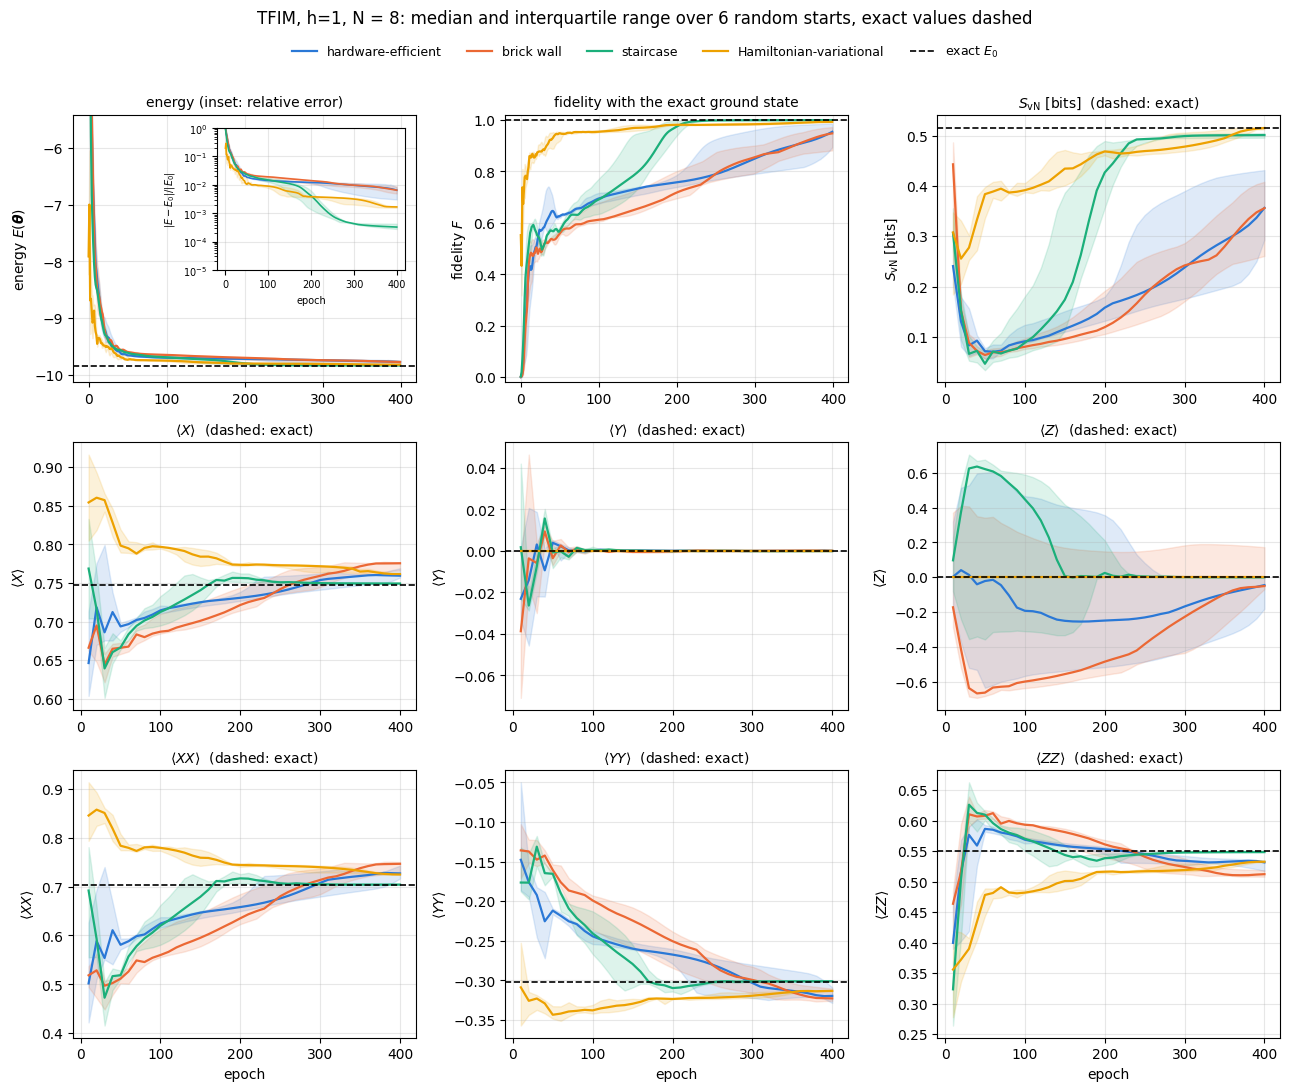

TFIM, h=1: exact E_0 = -9.83795, exact S_vN = +0.515, <X> = +0.748, <Y> = +0.000, <Z> = -0.000, <XX> = +0.703, <YY> = -0.302, <ZZ> = +0.551
                  ansatz  rel. error       F    S_vN     <X>     <Y>     <Z>    <XX>    <YY>    <ZZ>
      hardware-efficient    6.49e-03  0.9536  +0.356  +0.759  -0.000  -0.045  +0.727  -0.320  +0.532
              brick wall    6.48e-03  0.9475  +0.356  +0.776  +0.000  -0.051  +0.746  -0.323  +0.512
               staircase    3.25e-04  0.9991  +0.501  +0.749  -0.000  -0.000  +0.704  -0.301  +0.549
 Hamiltonian-variational    1.67e-03  0.9920  +0.515  +0.762  -0.000  -0.000  +0.725  -0.313  +0.533


In [10]:
# ==============================================================================
# STEP 7: one 3x3 figure per target
# ==============================================================================
EP = np.arange(N_EPOCHS)
EP_OBS = np.arange(1, N_EPOCHS // CHUNK + 1) * CHUNK


def training_figure(target, fig_no):
    ex = EXACT[target]
    fig, axes = plt.subplots(3, 3, figsize=(13.0, 10.5))
    ax = axes[0, 0]
    inset = ax.inset_axes([0.42, 0.42, 0.55, 0.53])
    for i, name in enumerate(ANSATZ_NAMES):
        r = RUNS[(name, target)]
        lo, med, hi = bands(r["E"])
        ax.fill_between(EP, lo, hi, color=PALETTE[i], alpha=0.15)
        ax.plot(EP, med, color=PALETTE[i], lw=1.6, label=name)
        lo, med, hi = bands(np.maximum((r["E"] - ex["E0"]) / abs(ex["E0"]), 1e-12))
        inset.fill_between(EP, lo, hi, color=PALETTE[i], alpha=0.15)
        inset.plot(EP, med, color=PALETTE[i], lw=1.2)
        lo, med, hi = bands(r["F"])
        axes[0, 1].fill_between(EP, lo, hi, color=PALETTE[i], alpha=0.15)
        axes[0, 1].plot(EP, med, color=PALETTE[i], lw=1.6)
        for m in range(7):
            a = axes.ravel()[m + 2]
            lo, med, hi = bands(r["obs"][:, :, m])
            a.fill_between(EP_OBS, lo, hi, color=PALETTE[i], alpha=0.15)
            a.plot(EP_OBS, med, color=PALETTE[i], lw=1.6)
    ax.axhline(ex["E0"], color="k", ls="--", lw=1.2, label="exact $E_0$")
    ax.set_ylim(ex["E0"] - 0.03 * abs(ex["E0"]), ex["E0"] + 0.45 * abs(ex["E0"]))
    ax.set_ylabel(r"energy $E(\boldsymbol{\theta})$"); ax.set_title("energy (inset: relative error)", fontsize=10)
    inset.set_yscale("log"); inset.set_ylim(1e-5, 1); inset.tick_params(labelsize=7)
    inset.set_xlabel("epoch", fontsize=7); inset.set_ylabel(r"$\vert E-E_0\vert/\vert E_0\vert$", fontsize=7)
    axes[0, 1].axhline(1.0, color="k", ls="--", lw=1.2)
    axes[0, 1].set_ylabel(r"fidelity $F$"); axes[0, 1].set_ylim(-0.02, 1.02)
    axes[0, 1].set_title("fidelity with the exact ground state", fontsize=10)
    for m in range(7):
        a = axes.ravel()[m + 2]
        a.axhline(ex["obs"][m], color="k", ls="--", lw=1.2)
        a.set_ylabel(OBS_TEX[m]); a.set_title(OBS_TEX[m] + "  (dashed: exact)", fontsize=10)
    for a in axes[-1]:
        a.set_xlabel("epoch")
    fig.suptitle(f"{target.replace('Delta', 'Δ')}, N = {N_SITES}: median and interquartile range over {R_STARTS} "
                 f"random starts, exact values dashed", y=1.035)
    handles, labels = ax.get_legend_handles_labels()
    fig.tight_layout()
    fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.012), fontsize=9)
    plt.show()


def final_table(target):
    ex = EXACT[target]
    print(f"{target}: exact E_0 = {ex['E0']:.5f}, exact " + ", ".join(f"{n} = {v:+.3f}" for n, v in zip(OBS_NAMES, ex["obs"])))
    print(f"{'ansatz':>24s} {'rel. error':>11s} {'F':>7s} " + " ".join(f"{n:>7s}" for n in OBS_NAMES))
    for name in ANSATZ_NAMES:
        r = RUNS[(name, target)]
        rel = np.median((r["E"][:, -1] - ex["E0"]) / abs(ex["E0"]))
        print(f"{name:>24s} {rel:11.2e} {np.median(r['F'][:, -1]):7.4f} "
              + " ".join(f"{v:+7.3f}" for v in np.median(r["obs"][:, -1, :], axis=0)))


training_figure("TFIM, h=1", 8)
final_table("TFIM, h=1")

**Figure 8.** Training on the critical Ising chain, $h=J=1$, $N=8$: median (line) and interquartile range (band) over
six random starts for each ansatz; dashed lines are the exact values.

**Critical Ising chain.** All four ansätze bring the energy within a few percent of $E_0$ during the first hundred
epochs, and at the scale of the total energy their curves are hard to tell apart; the inset separates them. After
$400$ epochs the staircase reaches a median relative error of $3.3\cdot10^{-4}$ with fidelity $0.9991$, the
Hamiltonian-variational ansatz $1.7\cdot10^{-3}$ with $0.992$, and the hardware-efficient and brick-wall circuits
$6.5\cdot10^{-3}$ with $0.954$ and $0.948$.

The state properties separate the ansätze more sharply than the energy. The hardware-efficient and brick-wall states
carry $0.356$ bits of half-chain entanglement against the exact $0.515$, $31\%$ too little, at an energy only
$0.65\%$ too high, and their median $\langle Z\rangle$ is $-0.045$ and $-0.051$ where the exact value is zero: these
states have not restored the parity symmetry. The Hamiltonian-variational state has exactly the right entanglement
(median $0.515$) and vanishing $\langle Y\rangle$, $\langle Z\rangle$ by construction; its remaining errors are in the
correlators, $\langle XX\rangle=0.725$ against $0.703$ and $\langle ZZ\rangle=0.533$ against $0.551$. The staircase reproduces every property to within
$0.015$. The entropy panel also shows *how* the circuits learn: for the three circuits started at random angles the
entanglement first drops to $0.05$ to $0.07$ bits within fifty to sixty epochs, as the optimiser aligns the spins with the field, and is rebuilt afterwards,
by the staircase between epochs $120$ and $230$ and by the hardware-efficient and brick-wall circuits so slowly that
their entropy is still rising at epoch $400$, while their energy has almost stopped moving.

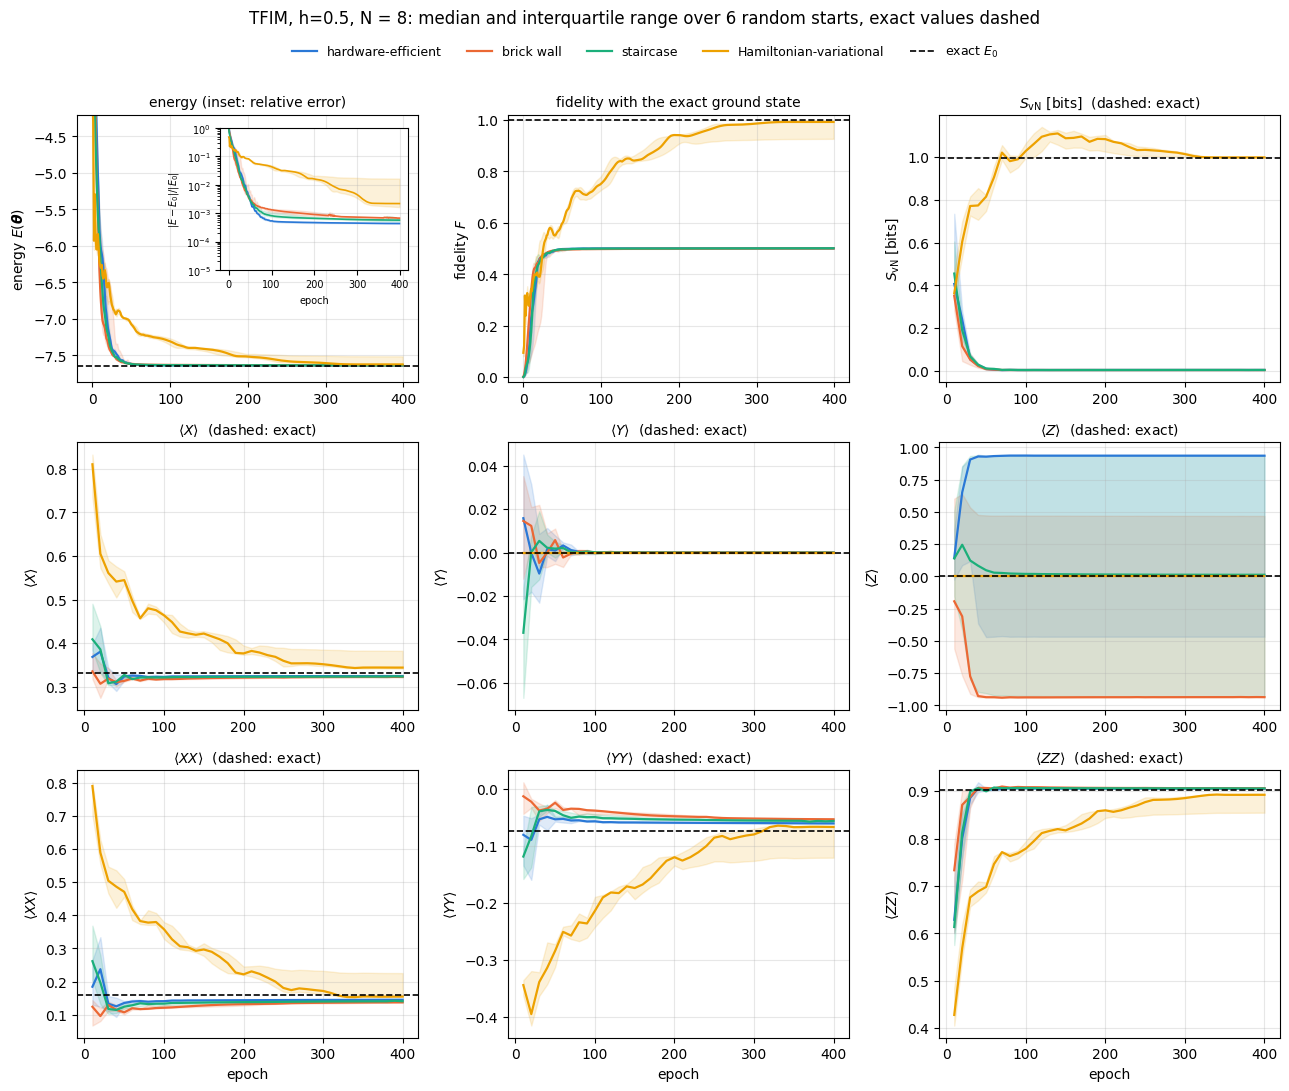

TFIM, h=0.5: exact E_0 = -7.64059, exact S_vN = +0.993, <X> = +0.331, <Y> = +0.000, <Z> = -0.000, <XX> = +0.161, <YY> = -0.074, <ZZ> = +0.902
                  ansatz  rel. error       F    S_vN     <X>     <Y>     <Z>    <XX>    <YY>    <ZZ>
      hardware-efficient    4.34e-04  0.5012  +0.004  +0.325  +0.000  +0.935  +0.145  -0.061  +0.905
              brick wall    6.72e-04  0.5002  +0.004  +0.323  +0.000  -0.936  +0.138  -0.054  +0.906
               staircase    5.70e-04  0.5011  +0.004  +0.324  -0.000  +0.012  +0.141  -0.057  +0.906
 Hamiltonian-variational    2.19e-03  0.9920  +0.998  +0.344  -0.000  +0.000  +0.155  -0.067  +0.892


In [11]:
training_figure("TFIM, h=0.5", 9)
final_table("TFIM, h=0.5")

**Figure 9.** Training on the ordered Ising chain, $h=0.5$, as in Figure 8.

**Ordered Ising chain.** On this target the energy misleads. The three ansätze without a built-in symmetry reach
relative energy errors of $4.3\cdot10^{-4}$ (hardware-efficient), $6.7\cdot10^{-4}$ (brick wall) and
$5.7\cdot10^{-4}$ (staircase), close to the best value of the whole experiment ($3.3\cdot10^{-4}$, the staircase on
the critical chain), and they pass $10^{-3}$ within $67$ to $161$ epochs; yet their fidelity with the exact ground
state stops at $0.500$. Their entanglement falls to $0.004$ bits against the exact $0.993$, and $\langle Z\rangle$
goes to $\pm0.935$, with a sign chosen by the random start: the band of the $\langle Z\rangle$ panel spans both signs,
and the medians are $+0.935$ (hardware-efficient), $-0.936$ (brick wall) and close to zero for the staircase, whose
starts split between the two signs. These states are ferromagnets that have broken the parity symmetry, close to
$(\vert\psi_0\rangle\pm\vert\psi_1\rangle)/\sqrt2$, a superposition of the cat state and its odd partner, which lies
only $0.0059$ higher (Section 4.4). The energy cannot tell them from the ground state at this resolution; Section 7.3
makes the bound explicit.

The Hamiltonian-variational ansatz cannot break the parity. It finds the cat state: median fidelity $0.992$ and
$S_{\mathrm{vN}}=0.998$ bits, with $\langle Z\rangle=0$ at every recorded epoch. Its energy error is larger, $2.2\cdot10^{-3}$, and
two of its six starts stop at fidelities $0.90$ and $0.77$: the circuit starts from $\vert+\rangle^{\otimes N}$, the
ground state of the paramagnet, and has to carry the state across the phase transition with $8$ layers, which takes
$229$ epochs (median of the four starts that get there) to reach a relative error of $10^{-2}$.

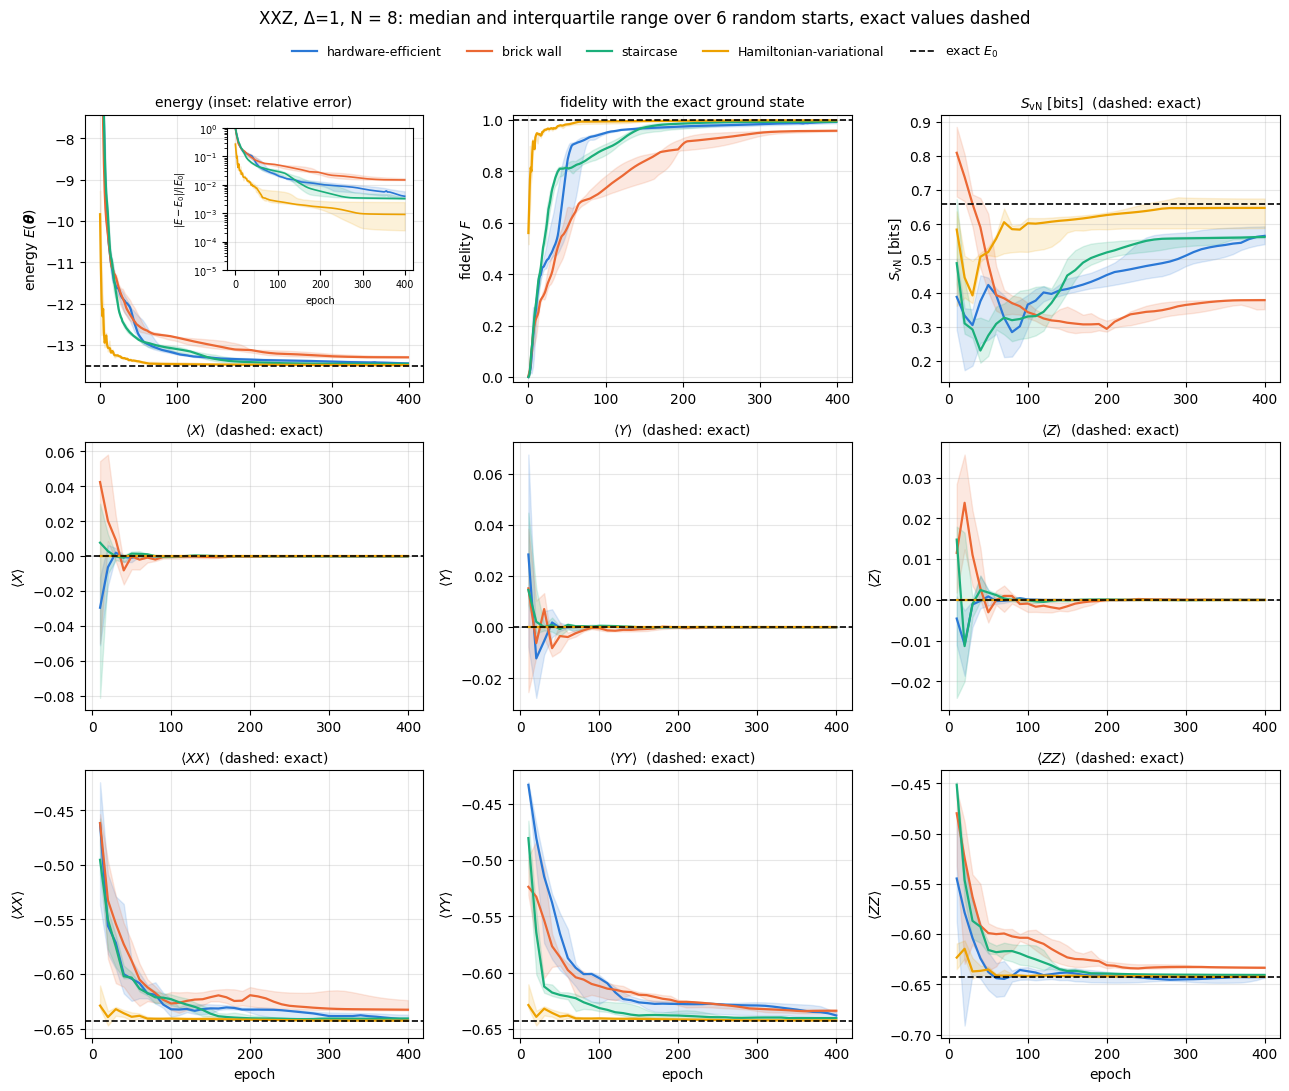

XXZ, Delta=1: exact E_0 = -13.49973, exact S_vN = +0.659, <X> = -0.000, <Y> = +0.000, <Z> = +0.000, <XX> = -0.643, <YY> = -0.643, <ZZ> = -0.643
                  ansatz  rel. error       F    S_vN     <X>     <Y>     <Z>    <XX>    <YY>    <ZZ>
      hardware-efficient    3.97e-03  0.9923  +0.566  -0.000  -0.000  -0.000  -0.641  -0.638  -0.643
              brick wall    1.49e-02  0.9578  +0.378  -0.000  -0.000  -0.000  -0.633  -0.634  -0.634
               staircase    3.28e-03  0.9927  +0.563  -0.000  +0.000  -0.000  -0.641  -0.641  -0.641
 Hamiltonian-variational    9.06e-04  0.9983  +0.648  +0.000  +0.000  -0.000  -0.643  -0.643  -0.643


In [12]:
training_figure("XXZ, Delta=1", 10)
final_table("XXZ, Delta=1")

**Figure 10.** Training on the Heisenberg chain, $\Delta=1$, as in Figure 8.

**Heisenberg chain.** The Hamiltonian-variational ansatz, $16$ angles started from the singlet product, reaches a
median relative error of $9.1\cdot10^{-4}$, fidelity $0.998$, $S_{\mathrm{vN}}=0.648$ bits against $0.659$, and the three
correlators equal to $-0.643$ to three digits. The hardware-efficient and staircase circuits reach $4.0\cdot10^{-3}$
and $3.3\cdot10^{-3}$ with fidelities $0.992$ and $0.993$, but their entanglement is $0.566$ and $0.563$ bits, $14\%$
short. The brick wall is the worst here: $1.5\cdot10^{-2}$, fidelity $0.958$ and $0.378$ bits, $43\%$ short. All
magnetisations vanish to three digits in every ansatz, so the $SU(2)$ symmetry is broken only weakly, visible as the
small spread $-0.641$, $-0.638$, $-0.643$ of the three correlators of the hardware-efficient state.

### 7.3 A small energy error does not mean the right state

The three figures repeat one observation: the energy converges first and furthest, and the state properties lag
behind. Two exact inequalities explain this.

**The energy bounds the infidelity, through the gap.** For a unique ground state with gap $\Delta_{\mathrm{gap}}=E_1-E_0$ (written with a subscript to distinguish it from the XXZ anisotropy),

$$E-E_0=\sum_{n\geq1}\lvert c_n\rvert^2(E_n-E_0)\;\geq\;\Delta_{\mathrm{gap}}\sum_{n\geq1}\lvert c_n\rvert^2=\Delta_{\mathrm{gap}}\,(1-F) , \tag{15}$$

from the expansion of Eq. (1) and $F=\lvert c_0\rvert^2$.
[Notebook 42](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb) derives the matching
upper bound in its Section 3.3 and the second-order relation $E-E_0=O(\varepsilon^2)$ for a state error
$\varepsilon$ in its Section 3.2. A measured energy error therefore certifies $1-F\le(E-E_0)/\Delta_{\mathrm{gap}}$, and a small gap
makes the certificate weak.

**Observables are bounded by the square root of the infidelity.** Let $\rho=\vert\psi\rangle\langle\psi\vert$ and
$\sigma=\vert\psi_0\rangle\langle\psi_0\vert$. In the plane spanned by the two vectors write
$\vert\psi\rangle=\sqrt F\vert\psi_0\rangle+\sqrt{1-F}\vert\psi_\perp\rangle$ (a global phase is irrelevant). In the
basis $\{\vert\psi_0\rangle,\vert\psi_\perp\rangle\}$ the difference $\rho-\sigma$ is the matrix with entries $-(1-F)$,
$\sqrt{F(1-F)}$, $\sqrt{F(1-F)}$, $1-F$; its trace is zero and its determinant $-(1-F)$, so its eigenvalues are
$\pm\sqrt{1-F}$. For any observable $A$ with largest absolute eigenvalue $\lVert A\rVert$,

$$\bigl\lvert\langle A\rangle_\psi-\langle A\rangle_0\bigr\rvert=\bigl\lvert\mathrm{Tr}\,A(\rho-\sigma)\bigr\rvert
  \;\leq\;\lVert A\rVert\sum\lvert\text{eigenvalues of }\rho-\sigma\rvert=2\lVert A\rVert\sqrt{1-F} . \tag{16}$$

The mean correlators of Section 4.4 have $\lVert A\rVert\le1$. Together, Eqs. (15) and (16) allow an observable error
of up to $2\sqrt{(E-E_0)/\Delta_{\mathrm{gap}}}$, which scales with the square root of the energy error. An energy error of $10^{-4}\Delta_{\mathrm{gap}}$ is compatible
with correlators wrong by $0.02$, and the entanglement entropy, a non-linear function of the state, has no protection
at all. When the gap is tiny, as in the ordered chain, Eq. (15) certifies nothing. The cell below checks both
inequalities on every recorded state of the two gapped targets, and checks the ordered chain against Eq. (15).

TFIM h=0.5: gap E_1 - E_0 = 0.00586;  a state with F = 1/2 has E - E_0 >= (1 - F) gap = gap/2, i.e. relative error >= 3.83e-04
                  ansatz  rel. error  (1-F) gap/|E_0|       F    S_vN   |<Z>|   (medians over starts)
      hardware-efficient    4.34e-04         3.83e-04  0.5012   0.004   0.935
              brick wall    6.72e-04         3.83e-04  0.5002   0.004   0.936
               staircase    5.70e-04         3.83e-04  0.5011   0.004   0.936
 Hamiltonian-variational    2.19e-03         6.14e-06  0.9920   0.998   0.000
exact (psi_0 + psi_1)/sqrt2: rel. error 3.83e-04, F = 0.5000, S_vN = 0.0053, |<Z>| = 0.934

1872 recorded states (TFIM h=1 and XXZ, all ansätze, all starts, epochs 10..390):
  Eq. (15): smallest (E - E_0) / [gap (1 - F)]               = 1.20   (must be >= 1)
  Eq. (16): largest correlator error / [2 sqrt(1 - F)]         = 0.35   (must be <= 1)
  control: the linear 'bound' correlator error <= 2 (1 - F) fails for 16% of the states (largest ratio 2.18)
  st

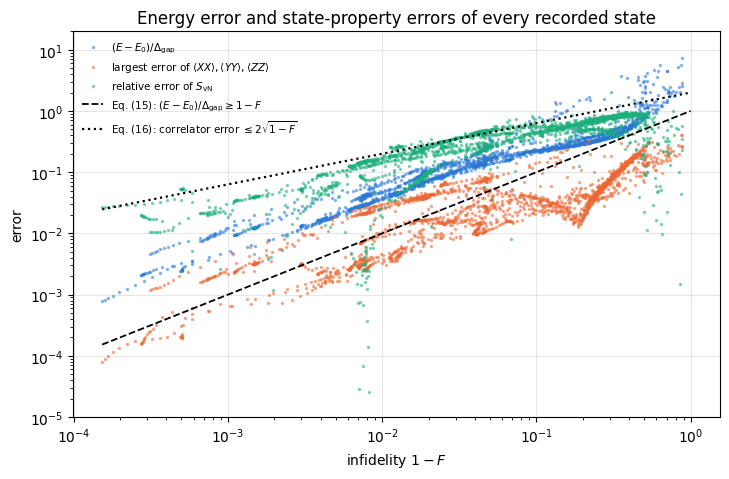

In [13]:
# ==============================================================================
# STEP 8: energy error against state error, run by run
# ==============================================================================
# --- (a) the ordered chain: every run of the three symmetry-breaking ansätze against the doublet bound ----------------
ex = EXACT["TFIM, h=0.5"]
print(f"TFIM h=0.5: gap E_1 - E_0 = {ex['gap']:.5f};  a state with F = 1/2 has E - E_0 >= (1 - F) gap = gap/2, "
      f"i.e. relative error >= {ex['gap'] / 2 / abs(ex['E0']):.2e}")
print(f"{'ansatz':>24s} {'rel. error':>11s} {'(1-F) gap/|E_0|':>16s} {'F':>7s} {'S_vN':>7s} {'|<Z>|':>7s}   (medians over starts)")
for name in ANSATZ_NAMES:
    r = RUNS[(name, "TFIM, h=0.5")]
    rel = (r["E"][:, -1] - ex["E0"]) / abs(ex["E0"])
    bound = (1 - r["F"][:, -1]) * ex["gap"] / abs(ex["E0"])
    print(f"{name:>24s} {np.median(rel):11.2e} {np.median(bound):16.2e} {np.median(r['F'][:, -1]):7.4f} "
          f"{np.median(r['obs'][:, -1, 0]):7.3f} {np.median(np.abs(r['obs'][:, -1, 3])):7.3f}")
    assert np.all(rel >= bound - 1e-12)                       # E - E_0 >= (1 - F) * gap, for every run
    if name != "Hamiltonian-variational":
        assert abs(np.median(r["F"][:, -1]) - 0.5) < 0.02 and np.median(r["obs"][:, -1, 0]) < 0.05 and np.all(rel < 2e-3)
w_d, V_d = np.linalg.eigh(np.asarray(model_matrix(TARGETS["TFIM, h=0.5"], N_SITES)))
phi_d = jnp.asarray((V_d[:, 0] + V_d[:, 1]) / np.sqrt(2), dtype=CDTYPE).reshape((2,) * N_SITES)   # doublet superposition
o_d = np.asarray(observables(phi_d))
print(f"{'exact (psi_0 + psi_1)/sqrt2':>27s}: rel. error {(float(energy(model_terms(N_SITES, TARGETS['TFIM, h=0.5']), phi_d)) - ex['E0']) / abs(ex['E0']):.2e}, "
      f"F = {float(fidelity_pure(ex['psi0'], phi_d)):.4f}, S_vN = {o_d[0]:.4f}, |<Z>| = {abs(o_d[3]):.3f}")

# --- (b) the targets with a sizeable gap: Eqs. (15) and (16) on every recorded state -----------------------------------
idx = np.arange(1, N_EPOCHS // CHUNK) * CHUNK        # epochs at which F and E refer to the state of an obs record
cloud = {"inf": [], "dE_gap": [], "dE_rel": [], "dS_rel": [], "dC": []}
for t in ("TFIM, h=1", "XXZ, Delta=1"):
    ex = EXACT[t]
    for name in ANSATZ_NAMES:
        r = RUNS[(name, t)]
        cloud["inf"].append((1 - r["F"][:, idx]).ravel())
        cloud["dE_gap"].append(((r["E"][:, idx] - ex["E0"]) / ex["gap"]).ravel())
        cloud["dE_rel"].append(((r["E"][:, idx] - ex["E0"]) / abs(ex["E0"])).ravel())
        cloud["dS_rel"].append((np.abs(r["obs"][:, :-1, 0] - ex["obs"][0]) / ex["obs"][0]).ravel())
        cloud["dC"].append(np.max(np.abs(r["obs"][:, :-1, 4:7] - ex["obs"][4:7]), axis=-1).ravel())
cloud = {k: np.concatenate(v) for k, v in cloud.items()}
r15 = np.min(cloud["dE_gap"] / cloud["inf"])
r16 = np.max(cloud["dC"] / (2 * np.sqrt(cloud["inf"])))
print(f"\n{cloud['inf'].size} recorded states (TFIM h=1 and XXZ, all ansätze, all starts, epochs 10..390):")
print(f"  Eq. (15): smallest (E - E_0) / [gap (1 - F)]               = {r15:.2f}   (must be >= 1)")
print(f"  Eq. (16): largest correlator error / [2 sqrt(1 - F)]         = {r16:.2f}   (must be <= 1)")
assert r15 >= 1 - 1e-9 and r16 <= 1 + 1e-9
lin = cloud["dC"] / (2 * cloud["inf"])                     # wrong control: a bound LINEAR in 1 - F, like the energy's
print(f"  control: the linear 'bound' correlator error <= 2 (1 - F) fails for {np.mean(lin > 1):.0%} of the states "
      f"(largest ratio {lin.max():.2f})")
assert np.mean(lin > 1) > 0.05
late = cloud["dE_rel"] < 1e-2
print(f"  states with relative energy error < 1e-2: {late.sum()};  among them the median relative error of S_vN is "
      f"{np.median(cloud['dS_rel'][late]):.3f} and {np.mean(cloud['dS_rel'][late] > 10 * cloud['dE_rel'][late]):.0%} "
      f"have a relative S_vN error more than ten times the relative energy error")

fig, ax = plt.subplots(figsize=(7.4, 4.9))
ax.loglog(cloud["inf"], cloud["dE_gap"], ".", ms=3, color=PALETTE[0], alpha=0.45, label=r"$(E-E_0)/\Delta_{\rm gap}$")
ax.loglog(cloud["inf"], cloud["dC"], ".", ms=3, color=PALETTE[1], alpha=0.45,
          label=r"largest error of $\langle XX\rangle,\langle YY\rangle,\langle ZZ\rangle$")
ax.loglog(cloud["inf"], cloud["dS_rel"], ".", ms=3, color=PALETTE[2], alpha=0.45,
          label=r"relative error of $S_{\rm vN}$")
xs = np.logspace(np.log10(cloud["inf"].min()), 0, 50)
ax.loglog(xs, xs, "k--", lw=1.3, label=r"Eq. (15): $(E-E_0)/\Delta_{\rm gap}\geq 1-F$")
ax.loglog(xs, 2 * np.sqrt(xs), "k:", lw=1.6, label=r"Eq. (16): correlator error $\leq 2\sqrt{1-F}$")
ax.set_xlabel(r"infidelity $1-F$"); ax.set_ylabel("error"); ax.set_ylim(1e-5, 20)
ax.set_title("Energy error and state-property errors of every recorded state")
ax.legend(fontsize=7.5, loc="upper left")
fig.tight_layout(); plt.show()

**Figure 11.** Every state recorded during training on the two gapped targets (four ansätze, six starts, epochs
$10$ to $390$): energy error in units of the gap, largest correlator error and relative entropy error against the
infidelity, with the bounds of Eqs. (15) and (16).

Both inequalities hold on all $1872$ recorded states of the two gapped targets: the smallest ratio
$(E-E_0)/[\Delta_{\mathrm{gap}}(1-F)]$ is $1.20$, and the largest correlator error is $0.35$ of its bound $2\sqrt{1-F}$. A bound
linear in the infidelity, like the energy's, would not hold: a correlator error below $2(1-F)$ fails for $16\%$ of the
states (largest ratio $2.2$). The figure shows the difference in scaling directly. The energy error (blue) lies above the dashed line of Eq. (15) and falls
roughly in proportion to the infidelity; the correlator errors (orange) stay below the dotted line of Eq. (16) and
fall more slowly; the relative error of the entanglement entropy (green) is the largest of all at small infidelity.
Among the $903$ recorded states whose energy is within $1\%$ of $E_0$, the median relative error of $S_{\mathrm{vN}}$
is $14\%$, and $95\%$ of them have a relative entropy error more than ten times their relative energy error.

For the ordered chain the printed table confirms Eq. (15) run by run with the doublet gap $\Delta_{\mathrm{gap}}=0.0059$: a state
with $F=1/2$ must have a relative error of at least $(1-F)\Delta_{\mathrm{gap}}/\lvert E_0\rvert=3.83\cdot10^{-4}$, and the
hardware-efficient states sit at $4.34\cdot10^{-4}$, within $15\%$ of this floor. They are almost exactly the
equal-weight superposition of the two doublet states, with little weight above the doublet. For comparison, the exact
superposition $(\vert\psi_0\rangle\pm\vert\psi_1\rangle)/\sqrt2$ has $F=1/2$, $\lvert\langle Z\rangle\rvert=0.934$
and $S_{\mathrm{vN}}=0.005$ bits, the values the three trained circuits reached. A relative energy error of
$4\cdot10^{-4}$ came with a fidelity of one half, the wrong entanglement and a non-zero order parameter.

> **Physics insight.** In the ordered phase of a finite chain the symmetry-broken state is the physically relevant
> one in a large system: as $N\to\infty$ the doublet becomes degenerate and any superposition is a ground state.
> The finite-chain fidelity of $1/2$ measures the overlap with the $N=8$ cat state; the trained states do describe the
> ordered phase. Notebook 42, Section 11, studies this regime in detail.

## 8. Comparison of the ansätze

The table collects, for every target and ansatz, the median final relative energy error with its interquartile
range, the median fidelity, the error of the median half-chain entropy, and the number of epochs needed to reach a
relative error of $10^{-2}$ and $10^{-3}$. After it, a short calculation tests the light-cone argument of Section 5.1.

In [14]:
# ==============================================================================
# STEP 9: the comparison table
# ==============================================================================
print(f"{'target':>13s} {'ansatz':>24s} {'n':>4s} {'median rel. err.':>16s} {'IQR':>21s} {'median F':>9s} "
      f"{'|dS_vN|':>8s} {'epochs to 1e-2':>15s} {'epochs to 1e-3':>15s}")
COMPARISON = {}
for t in TARGET_NAMES:
    ex = EXACT[t]
    for name in ANSATZ_NAMES:
        r = RUNS[(name, t)]
        rel = (r["E"] - ex["E0"]) / abs(ex["E0"])
        fin = rel[:, -1]
        e2, e3 = epochs_to(rel, 1e-2), epochs_to(rel, 1e-3)
        fmt = lambda e: f"{int(np.median(e[e >= 0])):4d} ({int((e >= 0).sum())}/{R_STARTS})" if (e >= 0).any() else f"  -- (0/{R_STARTS})"
        dS = abs(np.median(r["obs"][:, -1, 0]) - ex["obs"][0])
        COMPARISON[(t, name)] = dict(rel=np.median(fin), F=np.median(r["F"][:, -1]), dS=dS)
        print(f"{t:>13s} {name:>24s} {r['n']:4d} {np.median(fin):16.2e} [{np.percentile(fin, 25):.1e}, {np.percentile(fin, 75):.1e}] "
              f"{np.median(r['F'][:, -1]):9.4f} {dS:8.3f} {fmt(e2):>15s} {fmt(e3):>15s}")
print("(epochs to a relative error: median over the starts that reach it, and how many do)")


# --- CHECKPOINT 12: the light cone of the brick wall -- no connected correlation between the two ends ------------------
def connected_zz(psi, i, j):
    """<Z_i Z_j> - <Z_i><Z_j>."""
    return expect_pauli_string(psi, {i: "Z", j: "Z"}) - expect_pauli_string(psi, {i: "Z"}) * expect_pauli_string(psi, {j: "Z"})


end_corr = jax.jit(jax.vmap(lambda psi: connected_zz(psi, 0, N_SITES - 1)))      # one compilation for all states
states_of = {}                                                                  # one compiled circuit per ansatz
print(f"\nconnected end-to-end correlator <Z_0 Z_7> - <Z_0><Z_7>, median over the trained states")
print(f"{'target':>13s} {'exact':>8s} " + " ".join(f"{a:>24s}" for a in ANSATZ_NAMES))
for t, col in (("TFIM, h=1", 0), ("XXZ, Delta=1", 1)):
    vals = []
    for name in ANSATZ_NAMES:
        circ = ANSATZE[name][col]
        states_of.setdefault(circ, jax.jit(jax.vmap(circ)))
        vals.append(np.asarray(end_corr(states_of[circ](RUNS[(name, t)]["theta"]))))
    print(f"{t:>13s} {float(connected_zz(EXACT[t]['psi0'], 0, N_SITES - 1)):+8.4f} "
          + " ".join(f"{np.median(v):+24.4f}" for v in vals))
    assert np.max(np.abs(vals[ANSATZ_NAMES.index("brick wall")])) < 1e3 * TOL

       target                   ansatz    n median rel. err.                   IQR  median F  |dS_vN|  epochs to 1e-2  epochs to 1e-3
    TFIM, h=1       hardware-efficient  112         6.49e-03 [3.1e-03, 8.2e-03]    0.9536    0.159       272 (5/6)        -- (0/6)
    TFIM, h=1               brick wall  210         6.48e-03 [4.9e-03, 8.9e-03]    0.9475    0.159       298 (6/6)        -- (0/6)
    TFIM, h=1                staircase  210         3.25e-04 [2.8e-04, 4.3e-04]    0.9991    0.014       160 (6/6)       240 (6/6)
    TFIM, h=1  Hamiltonian-variational   16         1.67e-03 [1.5e-03, 1.8e-03]    0.9920    0.000        60 (6/6)        -- (0/6)
  TFIM, h=0.5       hardware-efficient  112         4.34e-04 [4.3e-04, 4.4e-04]    0.5012    0.989        37 (6/6)        67 (6/6)
  TFIM, h=0.5               brick wall  210         6.72e-04 [6.5e-04, 6.8e-04]    0.5002    0.990        32 (6/6)       161 (6/6)
  TFIM, h=0.5                staircase  210         5.70e-04 [5.1e-04, 6.2e-04] 

    TFIM, h=1  +0.1187                  +0.0128                  +0.0000                  +0.0939                  +0.0956


 XXZ, Delta=1  -0.1243                  -0.0595                  -0.0000                  -0.0566                  -0.1014


**Parameter count does not order the ansätze.** The Hamiltonian-variational circuits, with $16$ angles, give the best
Heisenberg state and the only correct ordered-Ising state, and they are the fastest to reach $10^{-2}$ on the
critical Ising chain ($60$ epochs) and on the Heisenberg chain ($37$ epochs). The brick wall and the staircase have
the same $210$ angles built from the same fifteen-angle blocks, yet the staircase is twenty times more accurate on
the critical Ising chain and four times on the Heisenberg chain.

**The light cone explains the brick wall.** With $L=2$ two-fold layers on eight qubits, a qubit at the left end is
coupled by the blocks only to qubits $0$ to $3$ when one traces back from qubit $0$ through the circuit, and qubit
$7$ only to qubits $4$ to $7$. The two backward light cones are disjoint, so the connected correlator
$\langle Z_0Z_7\rangle-\langle Z_0\rangle\langle Z_7\rangle$ vanishes exactly for *every* choice of the $210$ angles,
while the exact ground states have $+0.119$ (critical Ising) and $-0.124$ (Heisenberg). The checkpoint confirms the
zero on all trained brick-wall states. The hardware-efficient circuit is allowed this correlation by its light cone
but has not learned it: $+0.013$ on the Ising chain and $-0.060$ on the Heisenberg chain, against $+0.094$ and
$-0.057$ for the staircase and $+0.096$ and $-0.101$ for the Hamiltonian-variational states. The
staircase has no such restriction: its first sweep already connects the whole chain, which is why it does well on
the critical chain, whose correlations extend over the whole system. A third brick-wall layer closes the gap
(Exercise 3).

**Symmetry decides the ordered chain.** The three ansätze without a symmetry all found the symmetry-broken
ferromagnet, quickly and with energy errors below $7\cdot10^{-4}$. Only the parity-preserving circuit can represent
the cat state, and it pays with a slower start from the paramagnet. For the Heisenberg chain the singlet product with
$S^z_{\mathrm{tot}}$-conserving layers starts at $89\%$ of the ground-state energy and stays in the right symmetry
sector, so all of its angles work on the correlations inside the sector.

**The hardware-efficient circuit.** The two-qubit gates of the hardware-efficient circuit are fixed $CZ$
gates, so only single-qubit angles are trained. On the critical Ising chain it ends level with the brick wall, at $6.5\cdot10^{-3}$, and its
entanglement is still being built at epoch $400$; on the Heisenberg chain it is comparable to the staircase.

## 9. Barren plateaus in the energy landscape

All the runs above started from uniformly random angles and trained without difficulty at $N=8$. Whether this
survives larger $N$ is the question of **barren plateaus**: for many circuits the gradient of the cost, at random
angles, is exponentially small in the number of qubits. The theory is in
[notebook 40, Section 13](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb): the
mean of every gradient component over uniform angles is zero by periodicity, so its size is measured by the variance
$\mathrm{Var}_{\boldsymbol\theta}[\partial_kE]$; for circuits deep enough to act as unitary 2-designs the variance
decays exponentially (McClean *et al.*, 2018); and for shallow circuits the locality of the cost decides, with
global costs decaying exponentially and local ones at worst polynomially for depths logarithmic in $N$ (Cerezo
*et al.*, 2021, *Nat. Commun.*).
Noise produces plateaus of its own ([notebook 44, Section 8](../ch11_variational_quantum_circuits/44_noisy_variational_circuits.ipynb)).
Here we measure the variance for the cost of this notebook, the TFIM energy at $h=J=1$, a sum of $2N-1$ local terms.

**The 2-design reference.** Let $\theta_k$ be the angle of the first rotation $R_y(\theta_k)$ on qubit $0$, acting on
$\vert0\rangle^{\otimes N}$, and replace everything after it by a Haar-random unitary $W$ on the $d=2^N$-dimensional
space. Then $E=\mathrm{Tr}\,(W^\dagger HW\rho)$ with $\rho$ the state after the rotation, and
$\partial_kE=\mathrm{Tr}\,(W^\dagger HW\,B)$ with the traceless $B=\tfrac i2[\rho,Y_0]$. The second Haar moment,
$\mathbb E_W\bigl[\mathrm{Tr}(W^\dagger HWB)^2\bigr]=\mathrm{Tr}(H^2)\,\mathrm{Tr}(B^2)/(d^2-1)$ for traceless $H$ and
$B$, with $\mathrm{Tr}(B^2)=\tfrac12\bigl(1-\langle Y_0\rangle^2\bigr)=\tfrac12$ and
$\mathrm{Tr}(H^2)=d\sum_jc_j^2=d\bigl[(N-1)J^2+Nh^2\bigr]$, gives

$$\mathrm{Var}_{\mathrm{2\text{-}design}}[\partial_kE]=\frac{d\,\bigl[(N-1)J^2+Nh^2\bigr]}{2\,(d^2-1)}
  \;\approx\;\frac{(N-1)J^2+Nh^2}{2^{N+1}} , \tag{17}$$

an exponential decay $2^{-N}$ times a factor linear in $N$, because the energy has $2N-1$ terms. Checkpoint 9 tests
Eq. (17) against Haar-random unitaries at $N=2,4,6$.

**The measurement.** For each ansatz we draw $500$ angle vectors uniformly from $[-\pi,\pi]^n$, each from its own
PRNG key, and compute $\partial_kE$ for the angle of the first rotation on qubit $0$ ($\gamma_1$ for the
Hamiltonian-variational ansatz) by forward-mode differentiation, $\partial_kE=2\,\mathrm{Re}\langle\partial_k\psi\vert
H\vert\psi\rangle$ with $\vert\partial_k\psi\rangle$ from `jax.jvp`. Each variance is quoted with its standard error
$\sqrt{(\hat\mu_4-\widehat{\mathrm{Var}}^2)/R}$, as in notebook 40. The depth is either fixed, $L=2$, or grows with the
chain, $L=N$, for $N=2,4,6,8,10$. The same cell records the per-shot variance $\sigma^2$ of the energy measurement of
Eq. (9) at every sampled state, used below to count shots.

5 curves x 5 sizes (23 distinct circuits) x 500 samples in 51.3 s


CHECKPOINT 9, N=2: Haar-random circuit Var = 0.3739 +- 0.0195,  Eq. (17) = 0.4000


CHECKPOINT 9, N=4: Haar-random circuit Var = 0.2091 +- 0.0117,  Eq. (17) = 0.2196


CHECKPOINT 9, N=6: Haar-random circuit Var = 0.0845 +- 0.0052,  Eq. (17) = 0.0860
CHECKPOINT 10: largest |mean gradient| / SEM over all 23 sample sets = 2.57 (zero mean, < 4)

                         curve               N=2               N=4               N=6               N=8              N=10  b (N=4..10)
       hardware-efficient, L=2 3.494e-01+-2e-02 3.872e-01+-2e-02 3.619e-01+-2e-02 3.814e-01+-2e-02 3.862e-01+-2e-02        -0.00
       hardware-efficient, L=N 3.494e-01+-2e-02 3.398e-01+-2e-02 2.580e-01+-2e-02 1.826e-01+-1e-02 1.550e-01+-1e-02         0.19
               brick wall, L=2 4.017e-01+-2e-02 2.850e-01+-2e-02 2.107e-01+-1e-02 2.318e-01+-2e-02 2.290e-01+-1e-02         0.04
               brick wall, L=N 4.017e-01+-2e-02 2.323e-01+-2e-02 1.005e-01+-7e-03 3.671e-02+-2e-03 1.305e-02+-8e-04         0.70
  Hamiltonian-variational, L=N 7.509e+00+-3e-01 1.348e+01+-8e-01 2.331e+01+-1e+00 3.517e+01+-2e+00 5.360e+01+-4e+00        -0.33
            2-design, Eq. (17)         4.000e

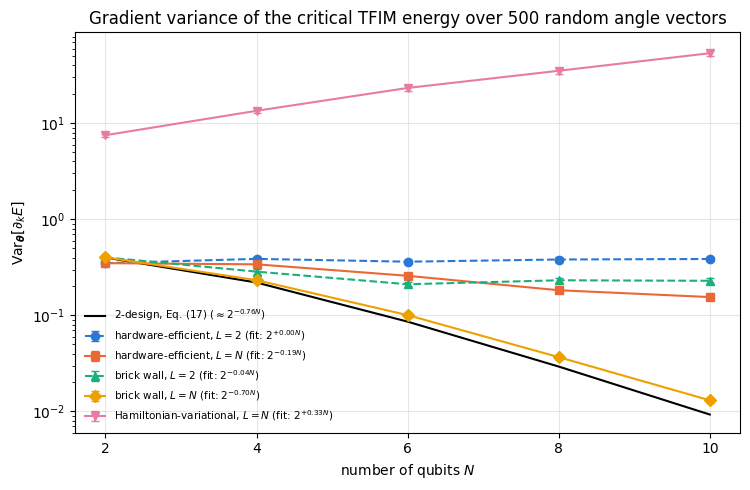

In [15]:
# ==============================================================================
# STEP 10: Var of one gradient component of the TFIM energy over random angles, N = 2..10
# ==============================================================================
N_LIST, R_BP, H_BP = (2, 4, 6, 8, 10), 500, 1.0


def single_shot_variance(psi, c):
    """sigma^2 = sum over the two TFIM settings of the per-shot variance of o_g, Eq. (9), from the Born distribution."""
    N = psi.ndim
    bits = all_bitstrings(N)
    p_z = jnp.abs(psi.reshape(-1)) ** 2
    rot = psi
    for q in range(N):
        rot = apply_gate(rot, H, [q])
    p_x = jnp.abs(rot.reshape(-1)) ** 2
    out = 0.0
    for p, basis in ((p_z, "Z"), (p_x, "X")):
        o = group_values(bits, c, basis)
        out = out + jnp.sum(p * o ** 2) - jnp.sum(p * o) ** 2
    return out


def gradient_samples(circuit, n, N, key, k=0):
    """dE/dtheta_k and sigma^2 at R_BP angle vectors drawn uniformly from [-pi, pi]^n, one PRNG key per sample.

    MATH   E = <psi|H|psi>  =>  dE/dtheta_k = 2 Re <d_k psi | H | psi>
    JAX    jax.jvp pushes the tangent e_k through the circuit (forward mode): memory O(2^N) per sample,
           independent of the depth, so vmap over hundreds of samples is cheap.
    """
    c = tfim_c(H_BP)
    terms = model_terms(N, c)
    e_k = jnp.zeros(n, dtype=RDTYPE).at[k].set(1.0)

    def one(key_s):
        th = jax.random.uniform(key_s, (n,), minval=-jnp.pi, maxval=jnp.pi, dtype=RDTYPE)
        psi, dpsi = jax.jvp(circuit, (th,), (e_k,))
        return 2.0 * jnp.real(jnp.vdot(dpsi, apply_hamiltonian(terms, psi))), single_shot_variance(psi, c)

    g, s2 = jax.jit(jax.vmap(one))(jax.random.split(key, R_BP))
    return np.asarray(g), np.asarray(s2)


def haar_variance(N, J=1.0, h=H_BP):
    """2-design value of Var[dE/dtheta] for the first rotation followed by a Haar-random unitary, Eq. (17)."""
    d = 2.0 ** N
    return d * ((N - 1) * J ** 2 + N * h ** 2) / (2 * (d * d - 1))


BP_ANSATZE = {   # label -> (circuit builder (N, L) -> theta -> state, parameter count, depths)
    "hardware-efficient": (lambda N, L: (lambda t: hea_scan(t, N, L)), lambda N, L: hea_num_params(N, L)),
    "brick wall": (lambda N, L: (lambda t: block_circuit(t, N, L, brick_bonds(N))), lambda N, L: 15 * L * (N - 1)),
    "Hamiltonian-variational": (lambda N, L: (lambda t: hva_tfim_scan(t, N, L)), lambda N, L: 2 * L),
}
BP_DEPTHS = {"hardware-efficient": ("2", "N"), "brick wall": ("2", "N"), "Hamiltonian-variational": ("N",)}
BP, BP_ERR, BP_S2, BP_Z = {}, {}, {}, []
BP_SAMPLES = {}                                            # (ansatz, N, L) -> samples; at N = 2 the depths L = 2 and L = N coincide
t_bp = time.perf_counter()
for a_i, (name, (builder, count)) in enumerate(BP_ANSATZE.items()):
    for depth in BP_DEPTHS[name]:
        key_curve = (name, depth)
        BP[key_curve], BP_ERR[key_curve], BP_S2[key_curve] = [], [], []
        for N in N_LIST:
            L = 2 if depth == "2" else N
            k_angle = 1 if name == "brick wall" else 0       # the R_y angle acting on qubit 0 first (gamma_1 for the HVA)
            if (name, N, L) not in BP_SAMPLES:
                BP_SAMPLES[(name, N, L)] = gradient_samples(builder(N, L), count(N, L), N, jax.random.PRNGKey(100 * a_i + N), k_angle)
                BP_Z.append(abs(BP_SAMPLES[(name, N, L)][0].mean()) / (BP_SAMPLES[(name, N, L)][0].std() / np.sqrt(R_BP)))
            g, s2 = BP_SAMPLES[(name, N, L)]
            v, se = var_with_error(g)
            BP[key_curve].append(v); BP_ERR[key_curve].append(se); BP_S2[key_curve].append(float(s2.mean()))
print(f"{len(BP)} curves x {len(N_LIST)} sizes ({len(BP_SAMPLES)} distinct circuits) x {R_BP} samples in {time.perf_counter() - t_bp:.1f} s")

# --- CHECKPOINT 9: the 2-design formula, Eq. (17), against Haar-random unitaries ---------------------------------
for N in (2, 4, 6):
    terms = model_terms(N, tfim_c(H_BP))

    def one(key_s):
        k1, k2 = jax.random.split(key_s)
        U = haar_unitary(k2, 2 ** N)
        cost = lambda t: energy(terms, (U @ apply_gate(zero_state(N), ry(t), [0]).reshape(-1)).reshape((2,) * N))
        return jax.grad(cost)(jax.random.uniform(k1, (), minval=-jnp.pi, maxval=jnp.pi, dtype=RDTYPE))

    v, se = var_with_error(np.asarray(jax.jit(jax.vmap(one))(jax.random.split(jax.random.PRNGKey(10_000 + N), R_BP))))
    print(f"CHECKPOINT 9, N={N}: Haar-random circuit Var = {v:.4f} +- {se:.4f},  Eq. (17) = {haar_variance(N):.4f}")
    assert abs(v - haar_variance(N)) < 4 * se
print(f"CHECKPOINT 10: largest |mean gradient| / SEM over all {len(BP_Z)} sample sets = {max(BP_Z):.2f} (zero mean, < 4)")
assert max(BP_Z) < 4

# --- table, fitted exponents, plot ------------------------------------------------------------------------------------
Ns = np.array(N_LIST, dtype=float)
print(f"\n{'curve':>30s} " + " ".join(f"{'N=' + str(N):>17s}" for N in N_LIST) + f" {'b (N=4..10)':>12s}")
fits = {}
for key_curve in BP:
    v = np.array(BP[key_curve])
    b = -np.polyfit(Ns[1:], np.log2(v[1:]), 1)[0]
    fits[key_curve] = b
    print(f"{key_curve[0] + ', L=' + key_curve[1]:>30s} "
          + " ".join(f"{x:9.3e}+-{e:5.0e}" for x, e in zip(v, BP_ERR[key_curve])) + f" {b:12.2f}")
v_haar = np.array([haar_variance(N) for N in N_LIST])
b_haar = -np.polyfit(Ns[1:], np.log2(v_haar[1:]), 1)[0]
print(f"{'2-design, Eq. (17)':>30s} " + " ".join(f"{x:17.3e}" for x in v_haar) + f" {b_haar:12.2f}")
assert fits[("brick wall", "N")] > 0.5 and abs(fits[("hardware-efficient", "2")]) < 0.2

fig, ax = plt.subplots(figsize=(7.6, 5.0))
for j, key_curve in enumerate(BP):
    ax.errorbar(Ns, BP[key_curve], yerr=BP_ERR[key_curve], fmt=MARKERS[j] + ("-" if key_curve[1] == "N" else "--"),
                ms=6, capsize=3, color=PALETTE[j],
                label=f"{key_curve[0]}, $L={key_curve[1]}$ (fit: $2^{{{-fits[key_curve]:+.2f}N}}$)")
ax.semilogy(Ns, v_haar, "k-", lw=1.5, label=rf"2-design, Eq. (17) ($\approx 2^{{-{b_haar:.2f}N}}$)")
ax.set_yscale("log"); ax.set_xticks(Ns)
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel(r"$\mathrm{Var}_{\boldsymbol{\theta}}[\partial_k E]$")
ax.set_title(f"Gradient variance of the critical TFIM energy over {R_BP} random angle vectors")
ax.legend(fontsize=7.5, loc="lower left")
fig.tight_layout(); plt.show()

**Figure 12.** Variance of one gradient component of the critical TFIM energy over $500$ uniformly random angle
vectors, with standard errors, at fixed depth $L=2$ (dashed) and depth $L=N$ (solid); black: the 2-design value of
Eq. (17). The legend gives the exponent $b$ of a fit $\mathrm{Var}\propto2^{-bN}$ over $N=4$ to $10$.

**Reading the measurement.** Checkpoint 9 confirms Eq. (17) at $N=2,4,6$, within $1.4$ standard errors, and the mean
gradient is zero within $2.6$ standard errors for every curve, as periodicity requires. The curves behave in four
different ways.

* **Shallow circuits do not flatten.** At $L=2$ the hardware-efficient variance stays between $0.35$ and $0.39$ from
  $N=2$ to $N=10$ (fitted exponent $b=0.00$ in $\mathrm{Var}\propto2^{-bN}$), and the brick wall settles at about
  $0.22$ from $N=6$ on. The first rotation influences only the energy terms inside its light cone, a number of terms
  fixed by $L$, so the gradient does not know how long the chain is. This is the local-cost result of notebook 40,
  Section 13.1, for the energy.
* **A brick wall of depth $N$ approaches the 2-design.** Its variance falls from $0.40$ to $0.013$, with $b=0.70$
  over $N=4$ to $10$, against $b=0.76$ for Eq. (17); at $N=10$ it is $1.4$ times the 2-design value. Fifteen-angle
  blocks with uniform angles scramble quickly, and $L=N$ layers are enough for the light cone to cover the chain
  several times.
* **The hardware-efficient circuit at $L=N$ decays slowly** ($b=0.19$, from $0.35$ to $0.155$). Its entangler is a
  fixed $CZ$ ladder, which spreads information by one site per layer and is far from a 2-design at these depths,
  consistent with the local-cost, $L=N$ measurement of notebook 40.
* **The Hamiltonian-variational variance grows with $N$** (from $7.5$ to $54$), because each of its angles is shared
  by all $N-1$ bond rotations of a layer, so one angle moves the whole energy. Wiersema *et al.* (2020) report mild or
  entirely absent barren plateaus for this ansatz family, with VQE experiments on the TFIM and XXZ chains.

**What a plateau costs.** On hardware a gradient component is estimated with the parameter-shift rule,
$\partial_kE=[E(\boldsymbol\theta+\tfrac\pi2\mathbf e_k)-E(\boldsymbol\theta-\tfrac\pi2\mathbf e_k)]/2$, from two
energies each estimated with $M$ shots per setting, Eq. (9). Its statistical variance is
$(\sigma_+^2+\sigma_-^2)/(4M)\approx\sigma^2/(2M)$. To resolve a typical gradient, of size
$\sqrt{\mathrm{Var}_{\boldsymbol\theta}[\partial_kE]}$, at signal-to-noise ratio one,

$$M^\star=\frac{\sigma^2}{2\,\mathrm{Var}_{\boldsymbol\theta}[\partial_kE]} \tag{18}$$

shots per setting and shifted circuit are needed. For a Haar-random state $\sigma^2=\frac{d}{d+1}\bigl[(N-1)J^2+Nh^2
\bigr]$, and Eqs. (17) and (18) give $M^\star\approx2^N$: every added qubit doubles the measurement cost of a single
gradient component. The cell evaluates Eq. (18) with the measured variances and the measured $\sigma^2$.

In [16]:
# ==============================================================================
# STEP 11: the number of shots needed to resolve one gradient component, Eq. (18)
# ==============================================================================
print(f"{'curve':>30s} " + " ".join(f"{'N=' + str(N):>9s}" for N in N_LIST) + "   (shots per setting and shifted circuit)")
for key_curve in BP:
    m_star = np.array(BP_S2[key_curve]) / (2 * np.array(BP[key_curve]))
    print(f"{key_curve[0] + ', L=' + key_curve[1]:>30s} " + " ".join(f"{m:9.3g}" for m in m_star))
s2_haar = np.array([2.0 ** N / (2.0 ** N + 1) * ((N - 1) + N * H_BP ** 2) for N in N_LIST])
m_haar = s2_haar / (2 * v_haar)
print(f"{'2-design':>30s} " + " ".join(f"{m:9.0f}" for m in m_haar))
for N_far in (20, 50):
    s2 = (N_far - 1) + N_far * H_BP ** 2
    print(f"2-design extrapolation, N = {N_far}: M* = {s2 / (2 * haar_variance(N_far)):.2e} shots")

                         curve       N=2       N=4       N=6       N=8      N=10   (shots per setting and shifted circuit)
       hardware-efficient, L=2      3.43       7.8      13.1      17.2      21.7
       hardware-efficient, L=N      3.43      9.07      19.9      39.2      59.3
               brick wall, L=2         3      11.1      24.5      30.5      39.1
               brick wall, L=N         3      14.1      53.4       204       726
  Hamiltonian-variational, L=N     0.211     0.251     0.223      0.21     0.179
                      2-design         3        15        63       255      1023
2-design extrapolation, N = 20: M* = 1.05e+06 shots
2-design extrapolation, N = 50: M* = 1.13e+15 shots


The table puts numbers on Eq. (18). A shallow hardware-efficient circuit needs $22$ shots per setting and shifted
circuit at $N=10$ to see its gradient above the shot noise, the brick wall of depth $N$ needs $726$, and the 2-design
reference $1023$, doubling with every qubit; extrapolated with Eqs. (17) and (18) the 2-design value is about
$10^6$ shots at $N=20$ and $10^{15}$ at $N=50$, for one component of one gradient. The Hamiltonian-variational
gradient is so large that a single shot resolves it. These are statements about the *start* of training, at random
angles; they decide whether the optimiser can leave the random region at all.

What helps is visible in the measurement and in the rest of this notebook:

* **shallow circuits with a local cost**: at fixed $L$ the energy gradient stopped decaying with $N$;
* **problem-inspired, parameter-sharing ansätze**: the Hamiltonian-variational gradient grew with $N$;
* **starting away from the uniform distribution**: the variance above is an average over uniformly random angles,
  and a start close to a good state, such as the small-angle start of the Hamiltonian-variational circuits in
  Section 7 or the warm starts of the next section, is not described by it.

> **Common pitfall.** A barren plateau is not cured by a better optimiser. Every optimiser on hardware has to resolve
> the gradient (or the energy differences) above the shot noise, and Eq. (18) prices that in measurements.

## 10. Scans across the phase diagrams with warm starts

A single ground state says little about a phase diagram. We now scan the transverse field of the Ising chain from
$h=2$ down to $h=0.1$ in $20$ steps, and the anisotropy of the XXZ chain from $\Delta=2$ down to $\Delta=-2$ in $21$
steps, with the hardware-efficient ansatz at $L=6$ and $N=8$. The first point is trained for $600$ epochs from a
random start; every following point starts from the optimal angles of the previous one and is trained for $200$
epochs (a **warm start**). Neighbouring Hamiltonians have neighbouring ground states, so the previous optimum is a good
starting point as long as the ground state changes continuously. Each scan is one
`lax.scan` over the grid, with the coefficient vector of the Hamiltonian as the scanned input, so the whole scan
compiles once. At every point we record the energy, the mean correlator $\langle Z_iZ_{i+1}\rangle$ and the
half-chain entropy, and compare them with exact diagonalisation.

Two ranges need care. In the ordered Ising regime the gap is the exponentially small doublet splitting, so the
energy hardly distinguishes the cat state from a broken-symmetry state (Section 7.3). For $\Delta<-1$ the XXZ ground
level is exactly degenerate: $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$ have the same energy, and any
superposition is a ground state, so the exact entropy is not defined there; $\langle Z_iZ_{i+1}\rangle=1$ holds on the
whole ground space. At $\Delta=-1$ the degeneracy is larger still. The figure greys out the degenerate points and
draws the exact entropy only where the ground state is unique.

In [17]:
# ==============================================================================
# STEP 12: warm-started VQE scans of h (TFIM) and Delta (XXZ) with the hardware-efficient ansatz
# ==============================================================================
L_SCAN, T_FIRST, T_POINT, LR_SCAN = 6, 600, 200, 0.05
H_GRID = np.round(np.linspace(2.0, 0.1, 20), 3)              # from the paramagnet into the ordered regime
D_GRID = np.round(np.linspace(2.0, -2.0, 21), 3)             # from the Neel side through the critical phase to the ferromagnet
scan_ansatz = lambda t: hea_scan(t, N_SITES, L_SCAN)


def zz_corr(psi):
    """Mean nearest-neighbour <Z_i Z_{i+1}>."""
    return jnp.mean(jnp.stack([expect_pauli_string(psi, {q: "Z", q + 1: "Z"}) for q in range(psi.ndim - 1)]))


def adam_steps(c, theta, n_steps):
    """n_steps Adam updates of the energy of model c (fresh moments), as a lax.scan."""
    g = jax.grad(lambda t: energy(model_terms(N_SITES, c), scan_ansatz(t)))

    def body(carry, k):
        t, m, v = carry
        gr = g(t)
        m, v = 0.9 * m + 0.1 * gr, 0.999 * v + 0.001 * gr ** 2
        return (t - LR_SCAN * (m / (1 - 0.9 ** k)) / (jnp.sqrt(v / (1 - 0.999 ** k)) + 1e-8), m, v), None

    (theta, _, _), _ = lax.scan(body, (theta, jnp.zeros_like(theta), jnp.zeros_like(theta)), jnp.arange(1, n_steps + 1))
    return theta


@jax.jit
def warm_scan(C, theta0):
    """Train at C[0] from theta0 for T_FIRST epochs, then at every C[i] for T_POINT epochs from the previous optimum."""
    theta = adam_steps(C[0], theta0, T_FIRST - T_POINT)

    def point(theta, c):
        theta = adam_steps(c, theta, T_POINT)
        psi = scan_ansatz(theta)
        return theta, jnp.stack([energy(model_terms(N_SITES, c), psi), zz_corr(psi),
                                 entanglement_entropy(psi, range(N_SITES // 2))])

    return lax.scan(point, theta, C)[1]


def exact_scan(C):
    """E_0, gap, <ZZ> and S_vN of the dense ground state at every coefficient vector."""
    rows = []
    for c in C:
        E0, E1, _, psi0 = exact_ground_state(c)
        o = np.asarray(observables(psi0))                      # o[6] = mean <Z_i Z_{i+1}>, o[0] = S_vN
        rows.append((E0, E1 - E0, o[6], o[0]))
    return np.array(rows)


theta0_scan = jax.random.uniform(jax.random.PRNGKey(77), (hea_num_params(N_SITES, L_SCAN),), minval=-jnp.pi, maxval=jnp.pi)
SCAN = {}
for label, grid, cfun in (("TFIM", H_GRID, tfim_c), ("XXZ", D_GRID, xxz_c)):
    C = jnp.stack([cfun(x) for x in grid])
    t0 = time.perf_counter()
    vqe = np.asarray(jax.block_until_ready(warm_scan(C, theta0_scan)))
    print(f"{label} scan, {len(grid)} points: {time.perf_counter() - t0:.1f} s")
    SCAN[label] = dict(grid=grid, vqe=vqe, ed=exact_scan(C))
w_m1 = np.linalg.eigvalsh(np.asarray(model_matrix(xxz_c(-1.0), N_SITES)))
print(f"XXZ at Delta = -1: degeneracy of the ground level = {int(np.sum(w_m1 < w_m1[0] + 1e-8))}")

# --- CHECKPOINT 11: the variational principle at every scan point -------------------------------------------------
for label in SCAN:
    d = SCAN[label]["vqe"][:, 0] - SCAN[label]["ed"][:, 0]
    print(f"CHECKPOINT 11 ({label}): min E - E_0 = {d.min():.1e}, max relative error = "
          f"{np.max(d / np.abs(SCAN[label]['ed'][:, 0])):.2e}")
    assert d.min() > -1e-9

print(f"\n{'h':>6s} {'rel. err.':>10s} {'gap':>9s} {'<ZZ> VQE':>9s} {'<ZZ> ED':>8s} {'S VQE':>7s} {'S ED':>7s}")
for x, v, e in zip(SCAN["TFIM"]["grid"], SCAN["TFIM"]["vqe"], SCAN["TFIM"]["ed"]):
    print(f"{x:6.2f} {(v[0] - e[0]) / abs(e[0]):10.2e} {e[1]:9.2e} {v[1]:+9.3f} {e[2]:+8.3f} {v[2]:7.3f} {e[3]:7.3f}")
print(f"\n{'Delta':>6s} {'rel. err.':>10s} {'gap':>9s} {'<ZZ> VQE':>9s} {'<ZZ> ED':>8s} {'S VQE':>7s} {'S ED':>7s}")
for x, v, e in zip(SCAN["XXZ"]["grid"], SCAN["XXZ"]["vqe"], SCAN["XXZ"]["ed"]):
    print(f"{x:6.2f} {(v[0] - e[0]) / abs(e[0]):10.2e} {e[1]:9.2e} {v[1]:+9.3f} {e[2]:+8.3f} {v[2]:7.3f} {e[3]:7.3f}")

TFIM scan, 20 points: 7.3 s


XXZ scan, 21 points: 7.5 s


XXZ at Delta = -1: degeneracy of the ground level = 9
CHECKPOINT 11 (TFIM): min E - E_0 = 5.8e-06, max relative error = 1.63e-03
CHECKPOINT 11 (XXZ): min E - E_0 = 7.8e-08, max relative error = 1.16e-02

     h  rel. err.       gap  <ZZ> VQE  <ZZ> ED   S VQE    S ED
  2.00   5.66e-04  2.19e+00    +0.250   +0.256   0.121   0.128
  1.90   4.85e-04  2.00e+00    +0.264   +0.270   0.134   0.141
  1.80   5.02e-04  1.80e+00    +0.280   +0.286   0.148   0.155
  1.70   5.59e-04  1.61e+00    +0.298   +0.304   0.162   0.173
  1.60   5.94e-04  1.42e+00    +0.318   +0.324   0.181   0.194
  1.50   6.31e-04  1.23e+00    +0.341   +0.348   0.206   0.220
  1.40   7.99e-04  1.05e+00    +0.367   +0.375   0.234   0.252
  1.30   1.03e-03  8.65e-01    +0.397   +0.408   0.267   0.294
  1.20   1.31e-03  6.89e-01    +0.434   +0.446   0.308   0.347
  1.10   1.32e-03  5.23e-01    +0.481   +0.493   0.371   0.419
  1.00   1.41e-03  3.69e-01    +0.539   +0.551   0.462   0.515
  0.90   1.37e-03  2.35e-01    +0.612   

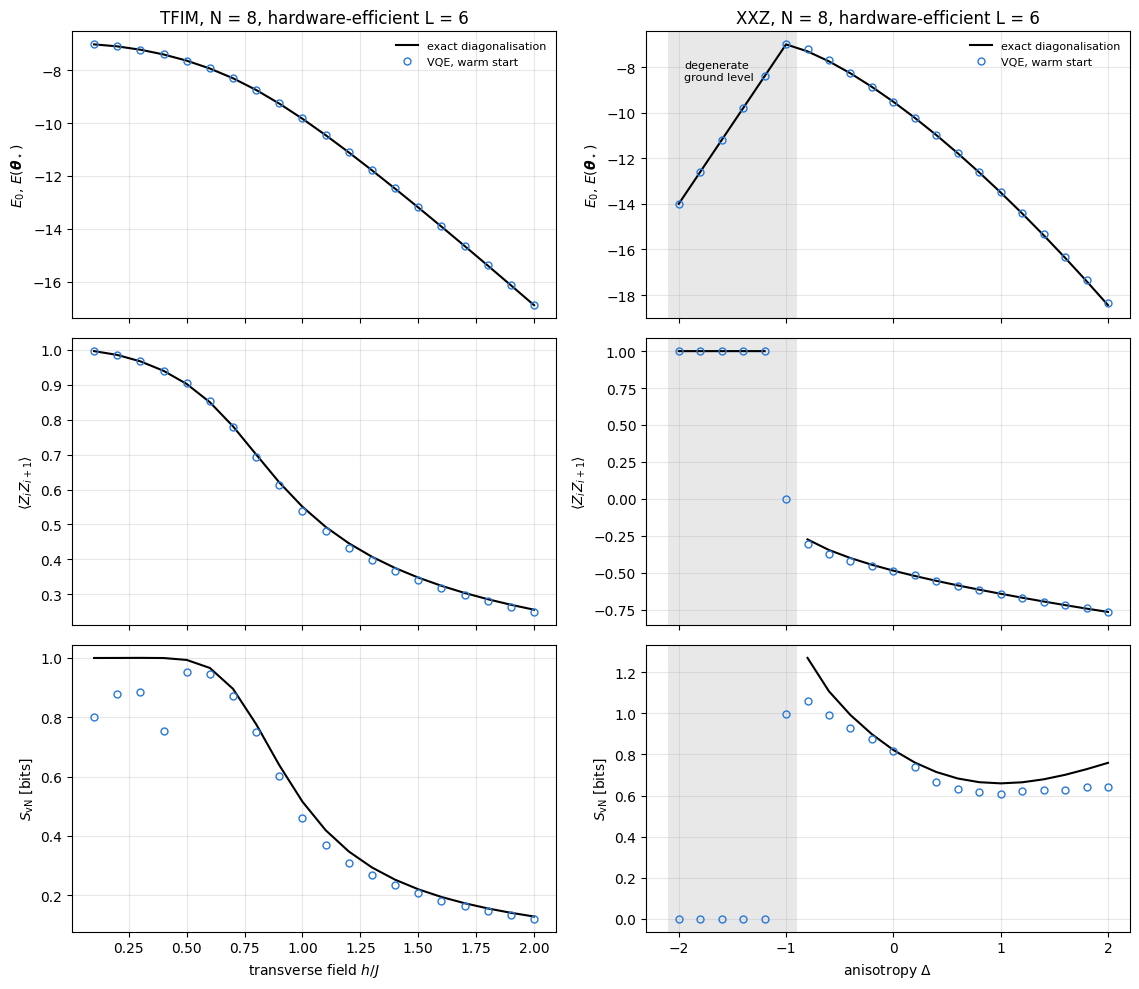

total wall time of the notebook so far: 229 s


In [18]:
# ==============================================================================
# STEP 13: the phase-scan figure (energy, <ZZ>, S_vN; TFIM left, XXZ right)
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(11.5, 10.0), sharex="col")
for col, (label, xlab) in enumerate((("TFIM", r"transverse field $h/J$"), ("XXZ", r"anisotropy $\Delta$"))):
    grid, vqe, ed = SCAN[label]["grid"], SCAN[label]["vqe"], SCAN[label]["ed"]
    degenerate = ed[:, 1] < 1e-8                                  # exactly degenerate ground level
    zz_defined = ~degenerate | (grid < -1.0)                      # <ZZ> = 1 on the whole ground space for Delta < -1
    for row in range(3):
        ax = axes[row, col]
        ref = ed[:, [0, 2, 3][row]].astype(float)
        mask = np.ones_like(grid, dtype=bool) if row == 0 else (zz_defined if row == 1 else ~degenerate)
        ax.plot(grid, np.where(mask, ref, np.nan), "k-", lw=1.5, label="exact diagonalisation")   # NaN breaks the line
        ax.plot(grid, vqe[:, row], MARKERS[0], ms=5, color=PALETTE[0], mfc="none", label="VQE, warm start")
        if degenerate.any():
            ax.axvspan(grid[degenerate].min() - 0.1, grid[degenerate].max() + 0.1, color="0.85", alpha=0.6, lw=0)
    axes[0, col].set_ylabel(r"$E_0$, $E(\boldsymbol{\theta}_\star)$")
    axes[1, col].set_ylabel(r"$\langle Z_iZ_{i+1}\rangle$")
    axes[2, col].set_ylabel(r"$S_{\rm vN}$ [bits]")
    axes[2, col].set_xlabel(xlab)
    axes[0, col].set_title(f"{label}, N = {N_SITES}, hardware-efficient L = {L_SCAN}")
    axes[0, col].legend(fontsize=8)
axes[0, 1].text(-1.95, axes[0, 1].get_ylim()[1] * 0.9 + axes[0, 1].get_ylim()[0] * 0.1, "degenerate\nground level",
                fontsize=8, va="top")
fig.tight_layout(); plt.show()
print(f"total wall time of the notebook so far: {time.perf_counter() - T_START:.0f} s")

**Figure 13.** Warm-started VQE scans (open circles) against exact diagonalisation (black lines). Left: Ising chain
from $h=2$ to $h=0.1$; right: XXZ chain from $\Delta=2$ to $\Delta=-2$. Rows: ground-state energy, mean
nearest-neighbour $\langle Z_iZ_{i+1}\rangle$, half-chain entropy. The grey band marks the exactly degenerate XXZ
ground level, $\Delta\le-1$, where the exact entropy is not defined.

**The Ising scan.** The energy follows the exact curve to a relative error of at most $1.6\cdot10^{-3}$ (at $h=0.7$
and $0.8$, in the crossover just below the critical point), and $\langle Z_iZ_{i+1}\rangle$ to within $0.012$ at every
field. As $h$ decreases, the exact entropy on the grid rises monotonically from $0.13$ bits at $h=2$ through $0.52$
at $h=1$ to $1.000$ bits (to the printed digits) for $h\le0.4$. An open chain of eight spins with a symmetric ground state therefore has no entropy maximum at
the critical point, because the cat state of the ordered side carries a full bit. (The logarithmic growth with $N$ at
the critical point is measured in notebook 11, Section 11.3.) The warm start carries a parity-symmetric state from the
paramagnet down to $h=0.5$, where the VQE entropy is $0.95$ bits against $0.99$. Below that, at $h\le0.4$, the VQE
entropy drops to between $0.76$ and $0.89$ bits while the exact value is one bit, and the energy error is only
$1.1\cdot10^{-4}$ to $8\cdot10^{-7}$: the doublet gap falls from $1.1\cdot10^{-3}$ to $2\cdot10^{-8}$, so by Eq. (15)
the energy no longer constrains how the state is spread over the doublet. The entropy is the quantity that shows it.

**The XXZ scan.** On the antiferromagnetic and critical side, $\Delta>-1$, the relative energy error stays below
$5.7\cdot10^{-3}$ down to $\Delta=-0.4$, reaches $6.5\cdot10^{-3}$ at $\Delta=-0.6$ and $1.2\cdot10^{-2}$ at $\Delta=-0.8$, the point closest to the
first-order transition; $\langle Z_iZ_{i+1}\rangle$ is within $0.03$ of the exact value. The exact entropy is smallest
near the Heisenberg point ($0.66$ bits at $\Delta=1$), larger on the Néel side ($0.76$ at $\Delta=2$, where the finite
chain's ground state is close to a superposition of the two Néel states) and largest as $\Delta\to-1^+$ ($1.27$ bits
at $\Delta=-0.8$). The VQE entropy lies below the exact one everywhere, by $0.01$ to $0.21$ bits, and the shortfall
is largest where the entanglement is largest. At $\Delta=-1$ the ground level is degenerate, and for $\Delta<-1$ the
warm-started circuit lands on a fully polarised state with $\langle Z_iZ_{i+1}\rangle=1$ and a relative energy error
below $10^{-6}$. Crossing the first-order transition from the critical side did not trap the optimiser here: the
hardware-efficient circuit does not conserve $S^z_{\mathrm{tot}}$, so it can move continuously from the
$S^z_{\mathrm{tot}}=0$ sector to the polarised states. A circuit that conserves $S^z_{\mathrm{tot}}$, like Eq. (13),
could not leave its sector at all. Run in the other direction, from $\Delta=-2$ upwards, the same warm-started
circuit leaves the polarised state at the transition but carries an almost unentangled state onto the critical side,
with relative energy errors of a few percent there (Exercise 5).

**Warm starts.** The scans needed $200$ epochs per point after the first, compared with the $400$ epochs from random
starts of Section 7, and reached comparable or better accuracy. They also carry information along the scan: the
symmetric state was kept far into the ordered regime because the previous point had it. The same mechanism can keep a
state on the wrong branch across a first-order transition; whether it does depends on the ansatz.

## 11. Key takeaways

* **The VQE minimises the energy of a circuit state**, $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert
  H\vert\psi(\boldsymbol\theta)\rangle\ge E_0$. Over $28\,800$ recorded energies the error never went below zero; the
  smallest value was $1.2\cdot10^{-3}$.
* **The energy is measured in a few settings.** The Ising chain needs two ($Z$ and $X$), the XXZ chain three, and the
  standard error falls as $M^{-1/2}$; at the Heisenberg ground state a relative accuracy of $10^{-2}$ on $E$ costs
  about $670$ shots per setting (Exercise 1).
* **The structure of an ansatz matters more than its parameter count.** With $16$ angles the Hamiltonian-variational ansätze gave the best Heisenberg
  state (relative error $9\cdot10^{-4}$, fidelity $0.998$) and the only correct ordered-Ising state. With the same
  $210$ angles a staircase of general blocks was twenty times more accurate than a brick wall on the critical Ising
  chain, because the two-layer brick wall cannot correlate the ends of the chain at all.
* **A small energy error is not a converged state.** At $h=0.5$ three ansätze reached relative errors of
  $4$ to $7\cdot10^{-4}$ with fidelity $0.500$, $0.004$ bits of entanglement instead of $0.99$, and
  $\lvert\langle Z\rangle\rvert=0.94$ instead of $0$. On the gapped targets, $95\%$ of the states with an energy within
  $1\%$ had an entropy error more than ten times larger. The reasons are $E-E_0\ge\Delta_{\mathrm{gap}}(1-F)$, Eq. (15), and
  $\lvert\Delta\langle A\rangle\rvert\le2\lVert A\rVert\sqrt{1-F}$, Eq. (16), both verified on every recorded state.
* **Barren plateaus depend on the circuit.** For the TFIM energy at random angles the gradient variance of shallow
  circuits did not decay with $N$; a brick wall of depth $N$ approached the 2-design value
  $\approx[(N-1)+N]/2^{N+1}$, Eq. (17), fitted exponent $0.70$ against $0.76$. Resolving a 2-design gradient costs
  $M^\star\approx2^N$ shots per setting, Eq. (18), about $10^{15}$ at $N=50$; the depth-$N$ brick wall already
  needed $726$ at $N=10$.
* **Warm-started scans** reproduce both phase diagrams at $N=8$ with relative energy errors below $1.6\cdot10^{-3}$
  (Ising) and $1.2\cdot10^{-2}$ (XXZ), with half the epochs per point. The entanglement entropy is again the quantity
  that reveals what the energy hides: in the ordered Ising regime and near the XXZ first-order transition.

For the rigorous relations between energy and state errors, symmetry leakage, depth studies, excited states and
training under shot noise, continue with
[notebook 42](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb); measuring the energy
with classical shadows is the subject of
[notebook 43](../ch11_variational_quantum_circuits/43_vqe_with_classical_shadows.ipynb), and noise of
[notebook 44](../ch11_variational_quantum_circuits/44_noisy_variational_circuits.ipynb).

## 12. Exercises

1. ★ **Shot budget at the ground state.** Use the exact per-setting variances of Eq. (9) at the Heisenberg ground
   state to find the number of shots per setting that gives a standard error of $10^{-2}\lvert E_0\rvert$ and of
   $10^{-3}\lvert E_0\rvert$. Check one of them with `estimate_energy`.
2. ★ **One staircase sweep.** Train the staircase with $L=1$ ($105$ angles) on the critical Ising chain and on the
   Heisenberg chain. Show that one sweep on $\vert0\rangle^{\otimes N}$ gives Schmidt rank at most two across every
   cut, and compare the trained entropies with the exact ones. Which target suffers, and why?
3. ★★ **The light cone (extend the code).** Find the smallest number of brick-wall layers for which the backward light
   cones of qubits $0$ and $7$ overlap. Train that circuit on the critical Ising chain and compare
   $\langle Z_0Z_7\rangle-\langle Z_0\rangle\langle Z_7\rangle$ with the exact value.
4. ★★ **Where the adiabatic path starts (physics).** In the ordered regime $h=0.5$, start the Ising
   Hamiltonian-variational circuit from the even cat state $(\vert0\cdots0\rangle+\vert1\cdots1\rangle)/\sqrt2$, the
   ground state of the coupling term in the $P=+1$ sector, instead of $\vert+\rangle^{\otimes N}$. Compare the
   relative energy error and the fidelity at $L=2,4,8$ layers, and explain the difference with the phase transition
   that the path from $\vert+\rangle^{\otimes N}$ must cross.
5. ★★ **The first-order transition from the other side (physics).** Repeat the XXZ scan of Section 10 from
   $\Delta=-2$ up to $\Delta=2$. Does the warm-started circuit leave the ferromagnet at $\Delta=-1$? Explain the result
   with the symmetry of the hardware-efficient circuit, and predict what a circuit conserving $S^z_{\mathrm{tot}}$
   would do.
6. ★★★ **A gradient in the middle of the circuit.** Repeat Section 9 for the hardware-efficient ansatz with
   $\theta_k$ the $R_y$ angle of qubit $N/2$ in the middle rotation block instead of the first rotation on qubit $0$.
   Does the shallow circuit still show no decay, and how does the $L=N$ curve change?

*Check values.* 1: the three settings have $\sum_g\sigma_g^2=12.1$, so $M\approx670$ and
$6.7\cdot10^4$. 2: Ising, four of six starts reach fidelity $0.998$ (median relative error $6.6\cdot10^{-4}$);
Heisenberg, every start stops at fidelity $0.70$, $S_{\mathrm{vN}}=0.375$ bits and relative error $5\cdot10^{-2}$.
3: $L=3$; five of six trained states give $0.08$ to $0.10$ against the exact $0.119$, at a median relative energy error
of $6\cdot10^{-4}$. 4: from the cat state the relative errors at $L=2,4,8$ are $2.3\cdot10^{-2}$, $4.0\cdot10^{-3}$,
$1.1\cdot10^{-3}$, from $\vert+\rangle^{\otimes N}$ $0.11$, $4.5\cdot10^{-2}$, $2.2\cdot10^{-3}$. 5: the circuit is
exact on the polarised side and at $\Delta=-1$; at $\Delta=-0.8$ it gives $\langle Z_iZ_{i+1}\rangle=-0.18$ (exact
$-0.275$), a relative error of $2\cdot10^{-2}$ and $0.03$ bits instead of $1.27$; the relative error stays between
$2\cdot10^{-2}$ and $4\cdot10^{-2}$ up to $\Delta=0$ and falls below $10^{-2}$ only from $\Delta=0.4$ on. The
trajectory after the degenerate point $\Delta=-1$ can depend on round-off, so other machines may give somewhat
different numbers. 6: the $L=2$ variance stays near $0.4$;
at $L=N$ it falls from $0.29$ ($N=4$) to $0.078$ ($N=10$), faster than for the first rotation.

## References

* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first VQE,
  on a photonic processor, for the ground-state energy of HeH$^+$.
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, *Hardware-efficient
  variational quantum eigensolver for small molecules and quantum magnets*, Nature **549**, 242 (2017) — the
  hardware-efficient ansatz, on up to six superconducting qubits.
* D. Wecker, M. B. Hastings and M. Troyer, *Progress towards practical quantum variational algorithms*, Phys. Rev. A
  **92**, 042303 (2015) — the ansatz motivated by adiabatic state preparation (Hamiltonian-variational ansatz).
* R. Wiersema, C. Zhou, Y. de Sereville, J. F. Carrasquilla, Y. B. Kim and H. Yuen, *Exploring entanglement and
  optimization within the Hamiltonian variational ansatz*, PRX Quantum **1**, 020319 (2020) — the ansatz for the TFIM
  and XXZ chains, its gradient statistics and trainability.
* F. Vatan and C. Williams, *Optimal quantum circuits for general two-qubit gates*, Phys. Rev. A **69**, 032315
  (2004) — any two-qubit gate with at most three CNOTs and single-qubit gates.
* R. Haghshenas, J. Gray, A. C. Potter and G. K.-L. Chan, *Variational power of quantum circuit tensor networks*,
  Phys. Rev. X **12**, 011047 (2022) — circuits shaped like matrix product states and MERA, compared with other
  architectures.
* E. Grant, M. Benedetti, S. Cao, A. Hallam, J. Lockhart, V. Stojevic, A. G. Green and S. Severini, *Hierarchical
  quantum classifiers*, npj Quantum Inf. **4**, 65 (2018) — tree-shaped circuits.
* J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush and H. Neven, *Barren plateaus in quantum neural network
  training landscapes*, Nat. Commun. **9**, 4812 (2018) — exponentially vanishing gradients of random circuits.
* M. Cerezo, A. Sone, T. Volkoff, L. Cincio and P. J. Coles, *Cost function dependent barren plateaus in shallow
  parametrized quantum circuits*, Nat. Commun. **12**, 1791 (2021) — global against local costs.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — review.
* J. Tilly, H. Chen, S. Cao, D. Picozzi, K. Setia, Y. Li, E. Grant, L. Wossnig, I. Rungger, G. H. Booth and
  J. Tennyson, *The variational quantum eigensolver: a review of methods and best practices*, Phys. Rep. **986**, 1
  (2022) — review of the VQE.
* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970) — the exact
  solution of the transverse-field Ising chain.
* J. Eisert, M. Cramer and M. B. Plenio, *Colloquium: Area laws for the entanglement entropy*, Rev. Mod. Phys. **82**,
  277 (2010).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/